In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model.repressilator import Repressilator, Repressilator_one_control
from model.pid import PID
from analysis.signal_analysis import *
from visualization.plotter import *
import tqdm
from scipy.optimize import fsolve

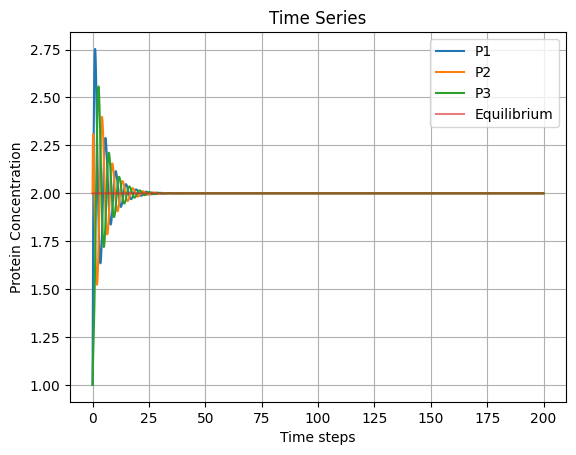

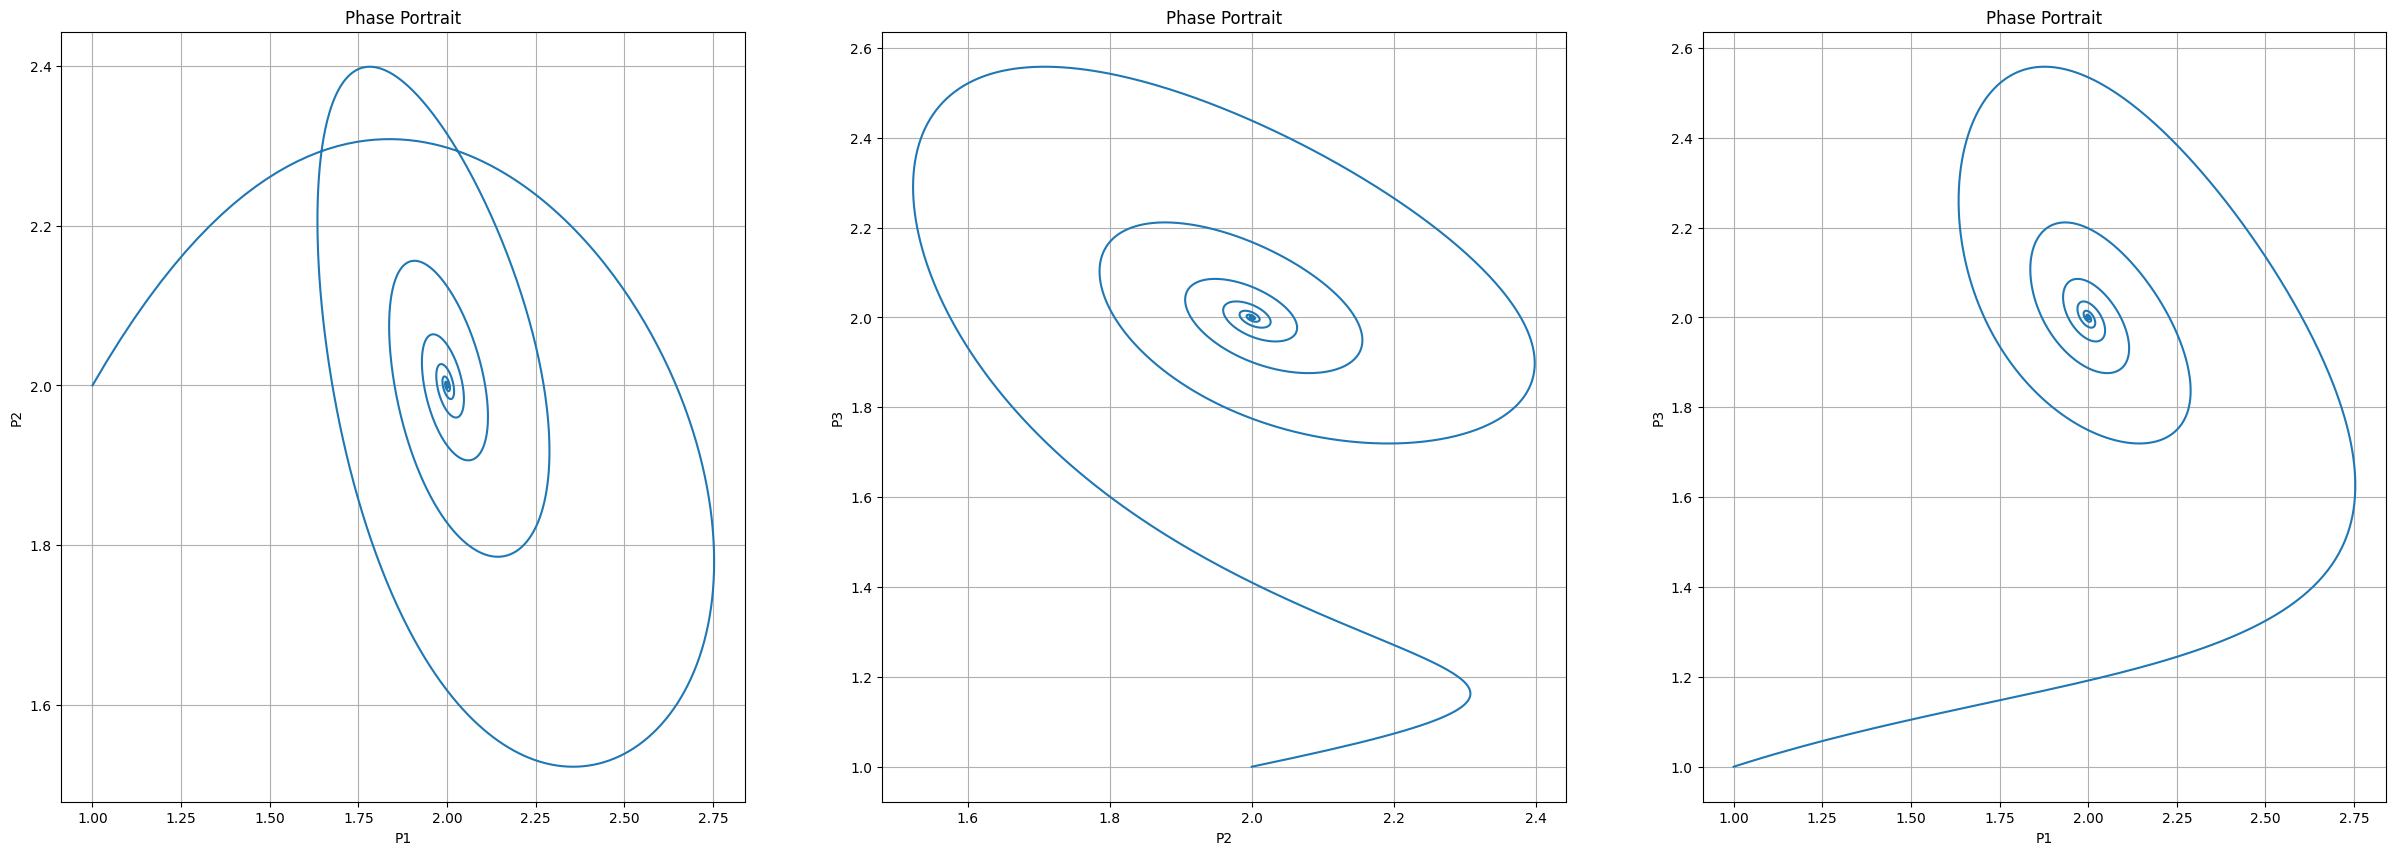

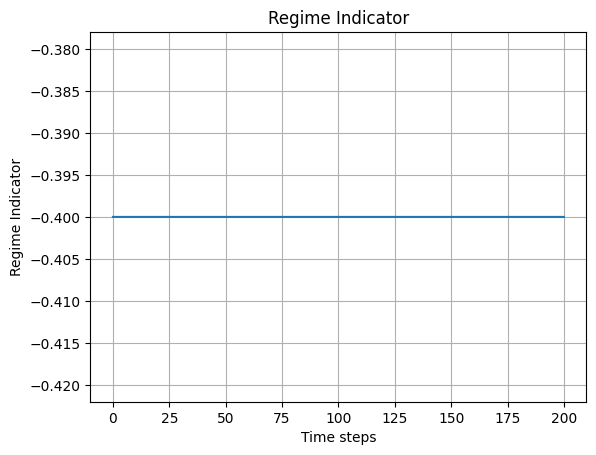

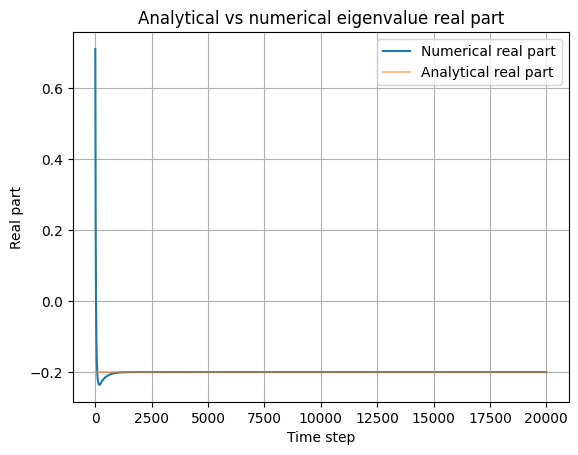

In [2]:
model = Repressilator()
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.simulate(initial_state)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)
hopf_comparison(model,state,u)

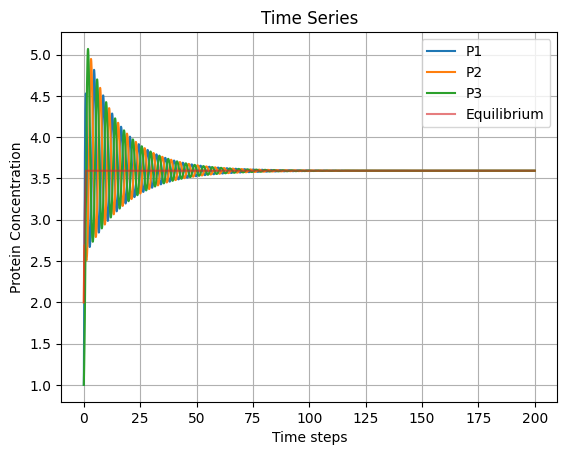

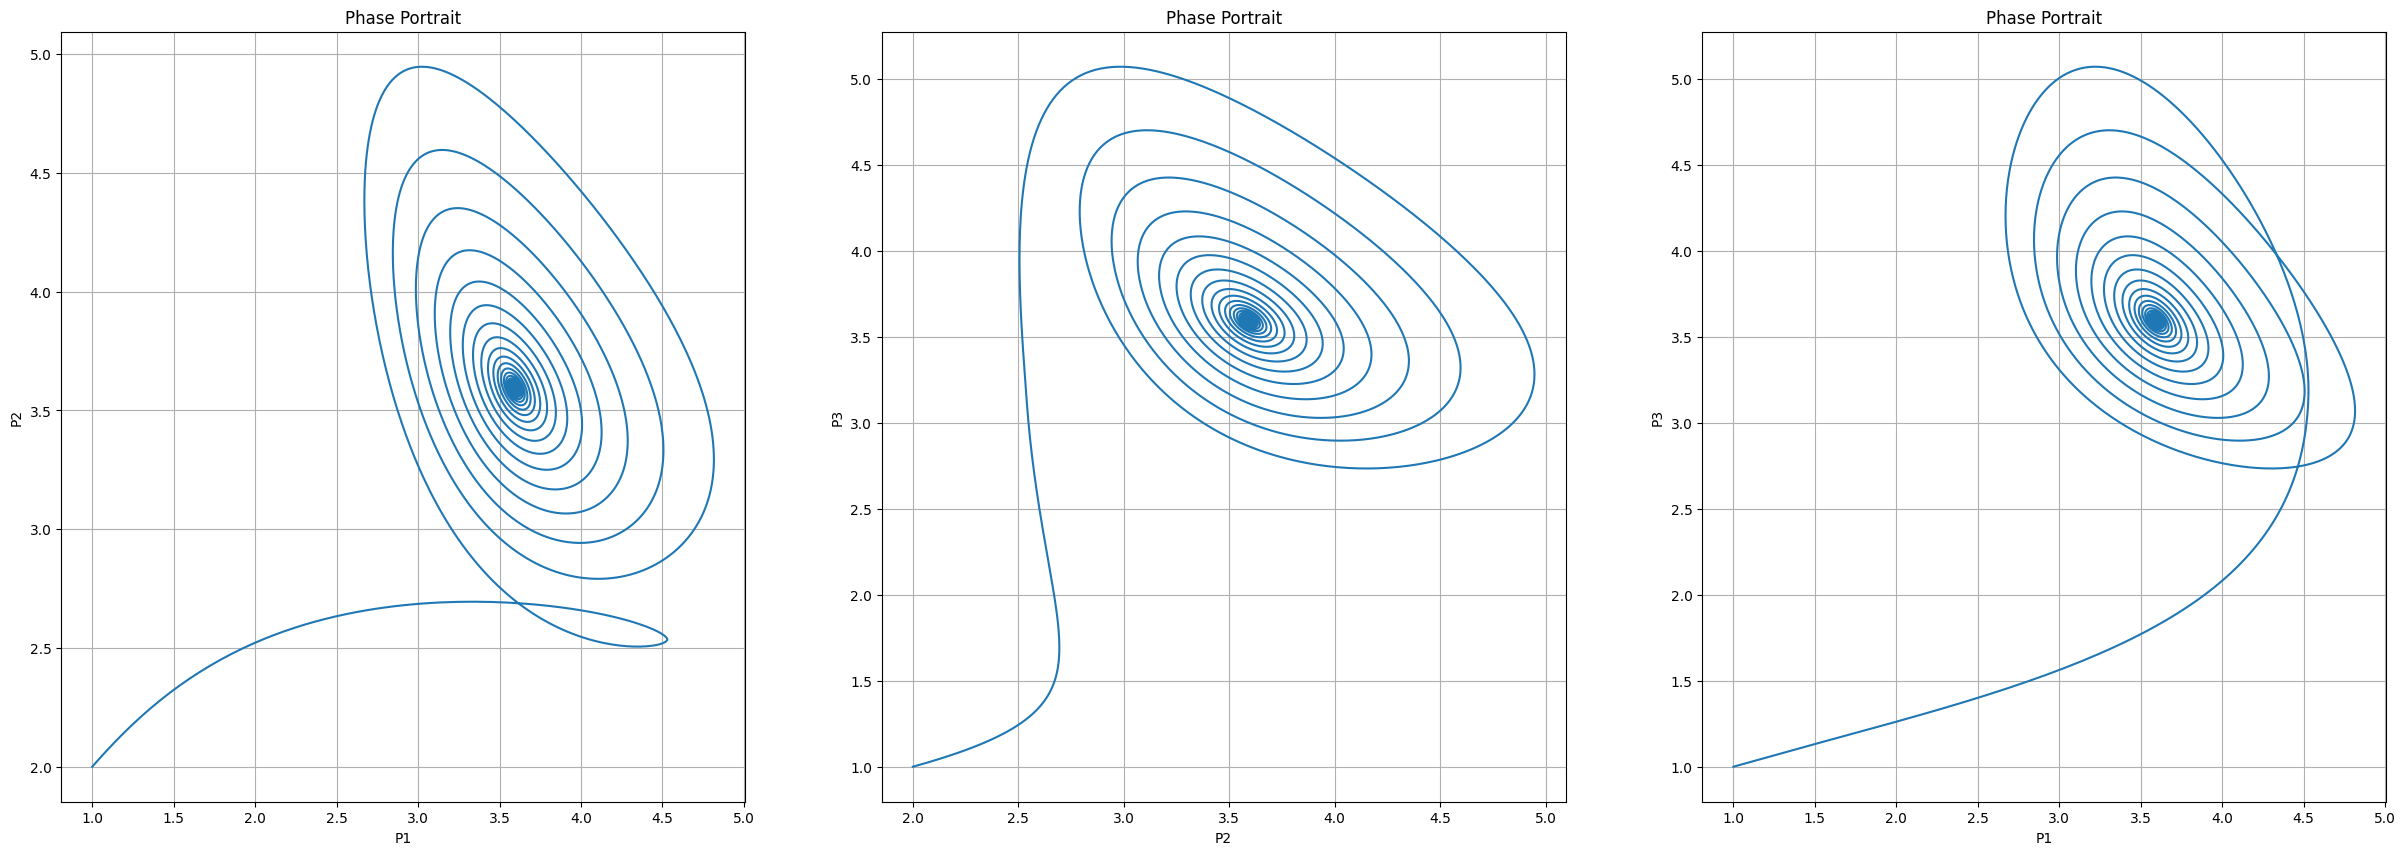

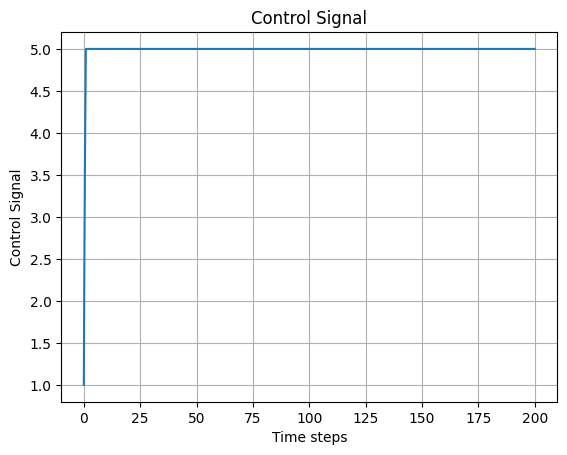

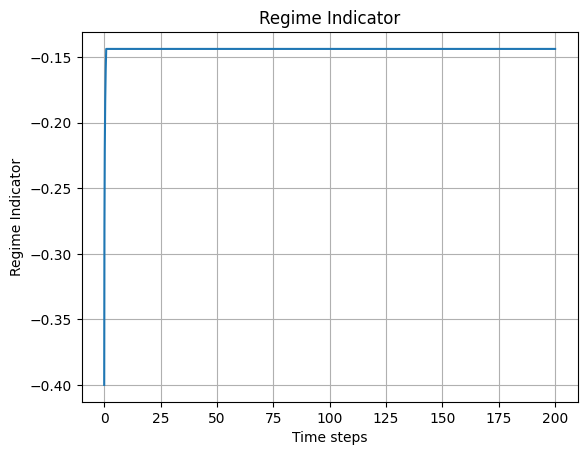

In [3]:
controller = PID(kp = 0.2, ki = 0, kd = 0, target_regime = 0.02)
model = Repressilator()

t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
control_signal(t, u)
regime_indicator(t, r)

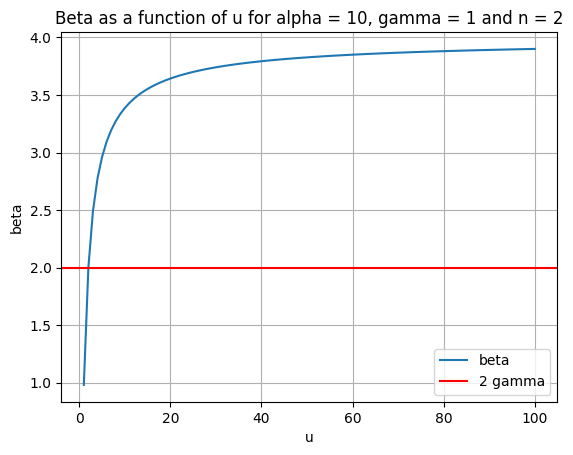

In [29]:
u_values = np.linspace(1, 100, 100)
beta = np.zeros(100)
for u in u_values:
    model = Repressilator(alpha = 1, gamma = 1, n = 4)
    beta[u_values == u] = model.beta(u)
plt.plot(u_values, beta, label = 'beta')
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.axhline(2 * model.gamma, color = 'red', label = '2 gamma')
plt.title('Beta as a function of u for alpha = 10, gamma = 1 and n = 2')
plt.legend()
plt.show()

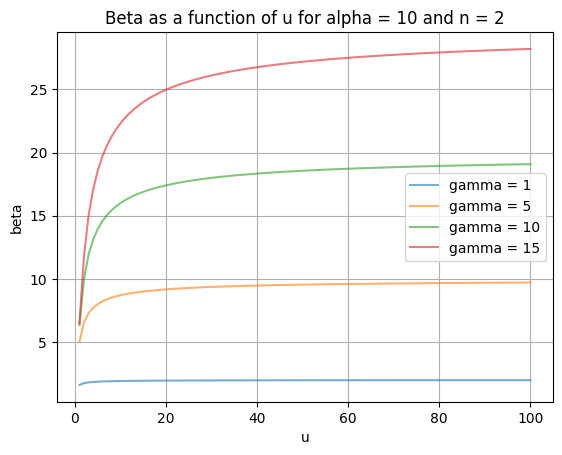

In [5]:
beta = np.zeros(100)
gamma_values = np.array([1, 5, 10, 15])
for gamma in gamma_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = 10, gamma = gamma, n = 2)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'gamma = {gamma}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for alpha = 10 and n = 2')
plt.legend()
plt.show()

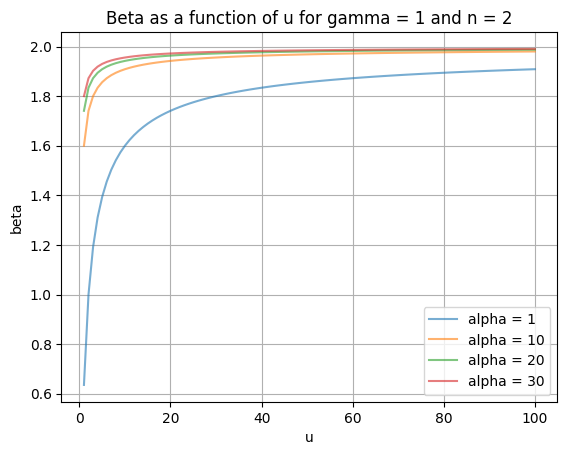

In [6]:
beta = np.zeros(100)
alpha_values = np.array([1, 10, 20, 30])
for alpha in alpha_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = alpha, gamma = 1, n = 2)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'alpha = {alpha}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for gamma = 1 and n = 2')
plt.legend()
plt.show()

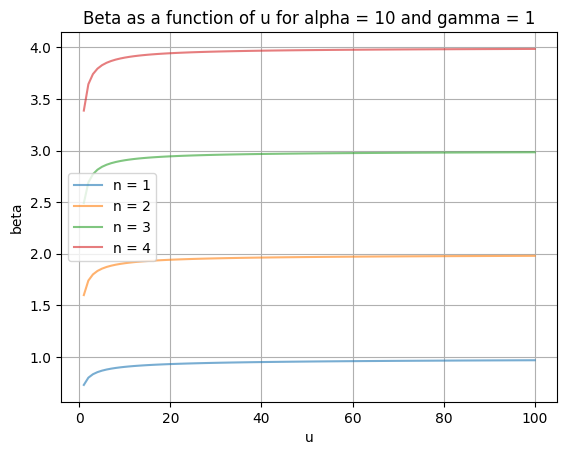

In [7]:
beta = np.zeros(100)
n_values = np.array([1, 2, 3, 4])
for n in n_values:
    u_values = np.linspace(1, 100, 100)
    for u in u_values:
        model = Repressilator(alpha = 10, gamma = 1, n = n)
        beta[u_values == u] = model.beta(u)
    plt.plot(u_values, beta, label = f'n = {n}', alpha = 0.6)
plt.xlabel("u")
plt.ylabel("beta")
plt.grid()
plt.title('Beta as a function of u for alpha = 10 and gamma = 1')
plt.legend()
plt.show()

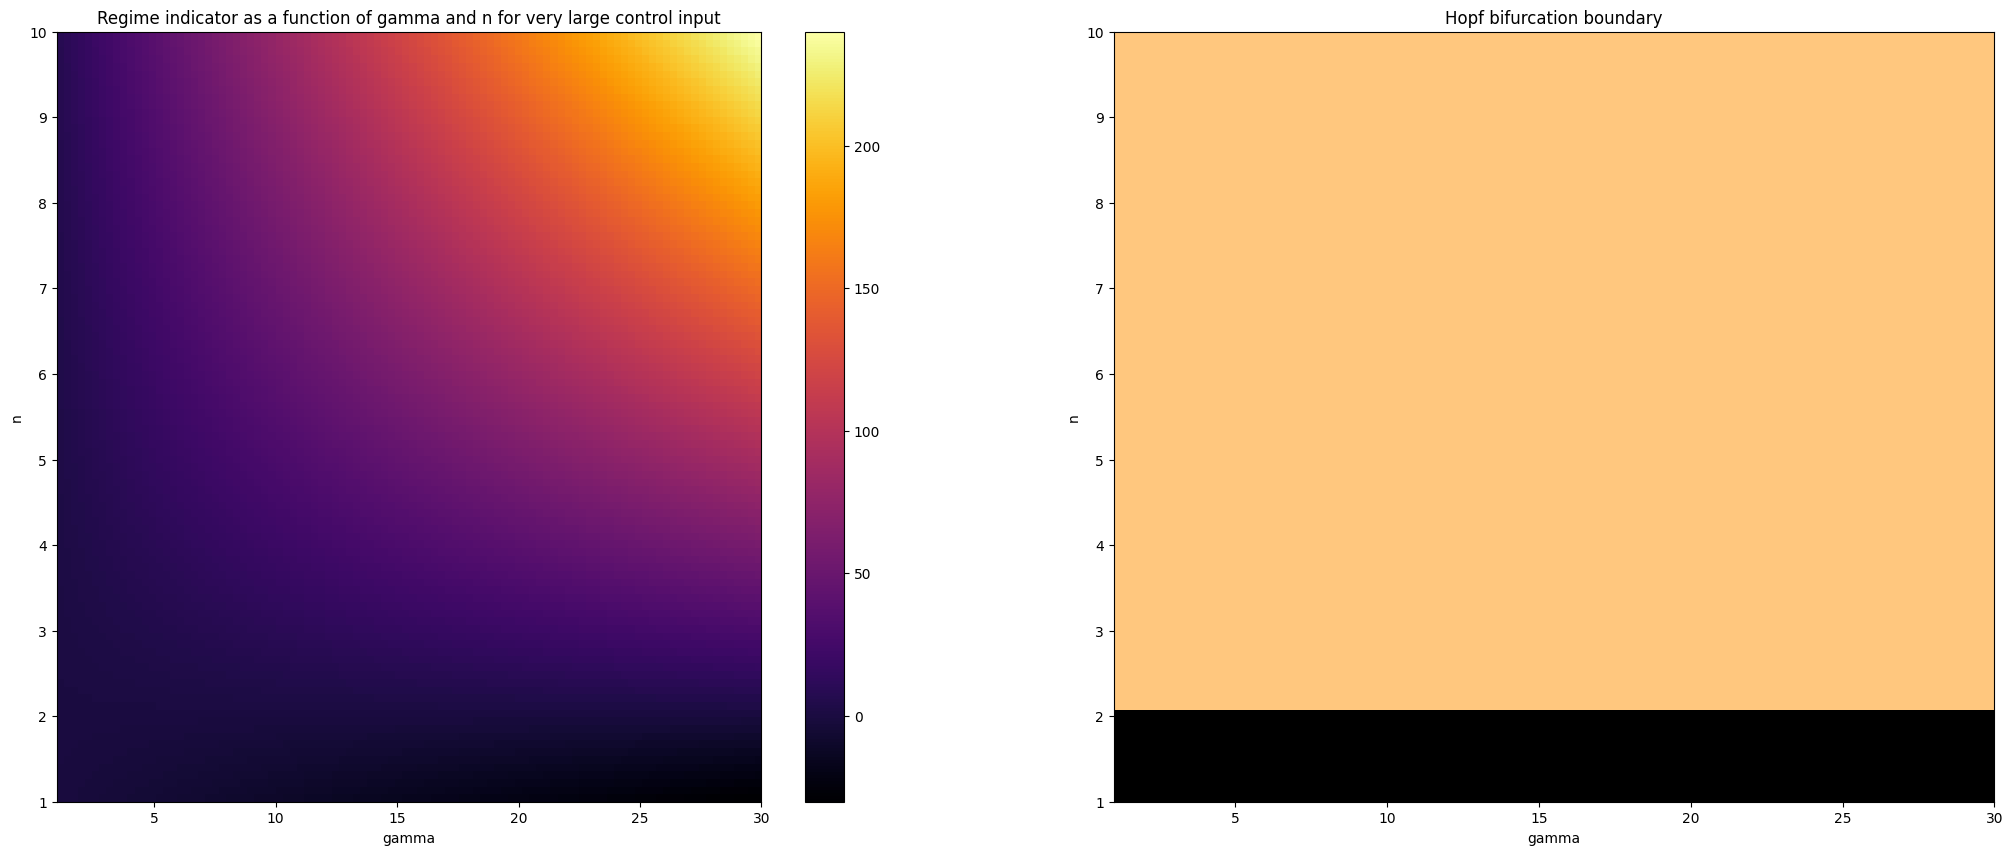

In [8]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
r = np.zeros((100,100))
u = 100000
for gamma in gamma_values:
    for n in n_values:
        model = Repressilator(alpha = 10, gamma = gamma, n = n)
        r[n_values == n, gamma_values == gamma] = model.beta(u) - 2 * gamma

r_mask = np.zeros((100,100))
r_mask[r == 0] = 1
r_mask[r > 0] = 2
plt.figure(figsize = (25, 10))
plt.subplot(1,2,1)
plt.imshow(r, extent = [1, 30, 1, 10], aspect = 'auto', cmap = 'inferno', origin = 'lower')
plt.xlabel("gamma")
plt.ylabel("n")
plt.colorbar()
plt.title('Regime indicator as a function of gamma and n for very large control input')
plt.subplot(1,2,2)
plt.imshow(r_mask, extent = [1, 30, 1, 10], aspect = 'auto', cmap = 'copper', origin = 'lower')
plt.xlabel("gamma")
plt.ylabel("n")
plt.title('Hopf bifurcation boundary')
plt.show()

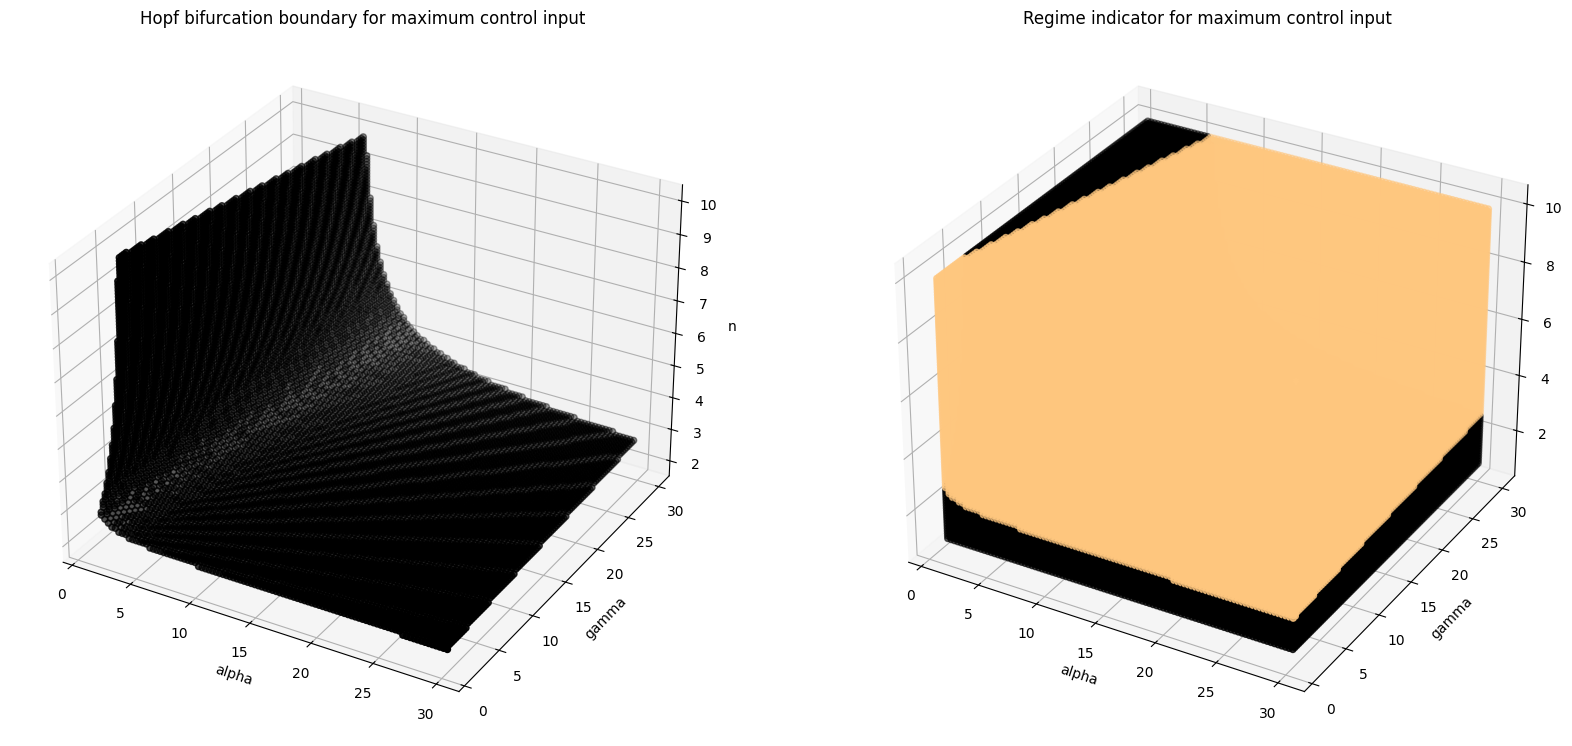

In [9]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
alpha_values = np.linspace(1, 30, 100)
r = np.zeros((100,100,100))
u = 5
for i, gamma in enumerate(gamma_values):
    for k, n in enumerate(n_values):
        for j, alpha in enumerate(alpha_values):
            model = Repressilator(alpha = alpha, gamma = gamma, n = n)
            r[j,i,k] = model.beta(u) - 2 * gamma

r_mask = np.zeros((100,100,100))
r_mask[r > 0] = 1
surface = np.zeros((100,100,100), dtype = bool)

for i in range(1,99):
    for j in range(1,99):
        for k in range(1,99):
            if r_mask[i,j,k] == 1:
                surface[i,j,k] = 1 - r_mask[i-1,j,k] * r_mask[i+1,j,k] * r_mask[i,j-1,k] * r_mask[i,j+1,k] * r_mask[i,j,k-1] * r_mask[i,j,k+1]



fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(1,2,1, projection='3d')
X,Y ,Z = np.meshgrid(alpha_values, gamma_values, n_values, indexing = 'ij')
ax.scatter(X[surface], Y[surface], Z[surface], color = 'black')
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Hopf bifurcation boundary for maximum control input')

ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(X,Y,Z, c=r_mask, cmap='copper')
ax2.set_xlabel('alpha')
ax2.set_ylabel('gamma')
ax2.set_zlabel('n')
ax2.set_title('Regime indicator for maximum control input')

plt.show()

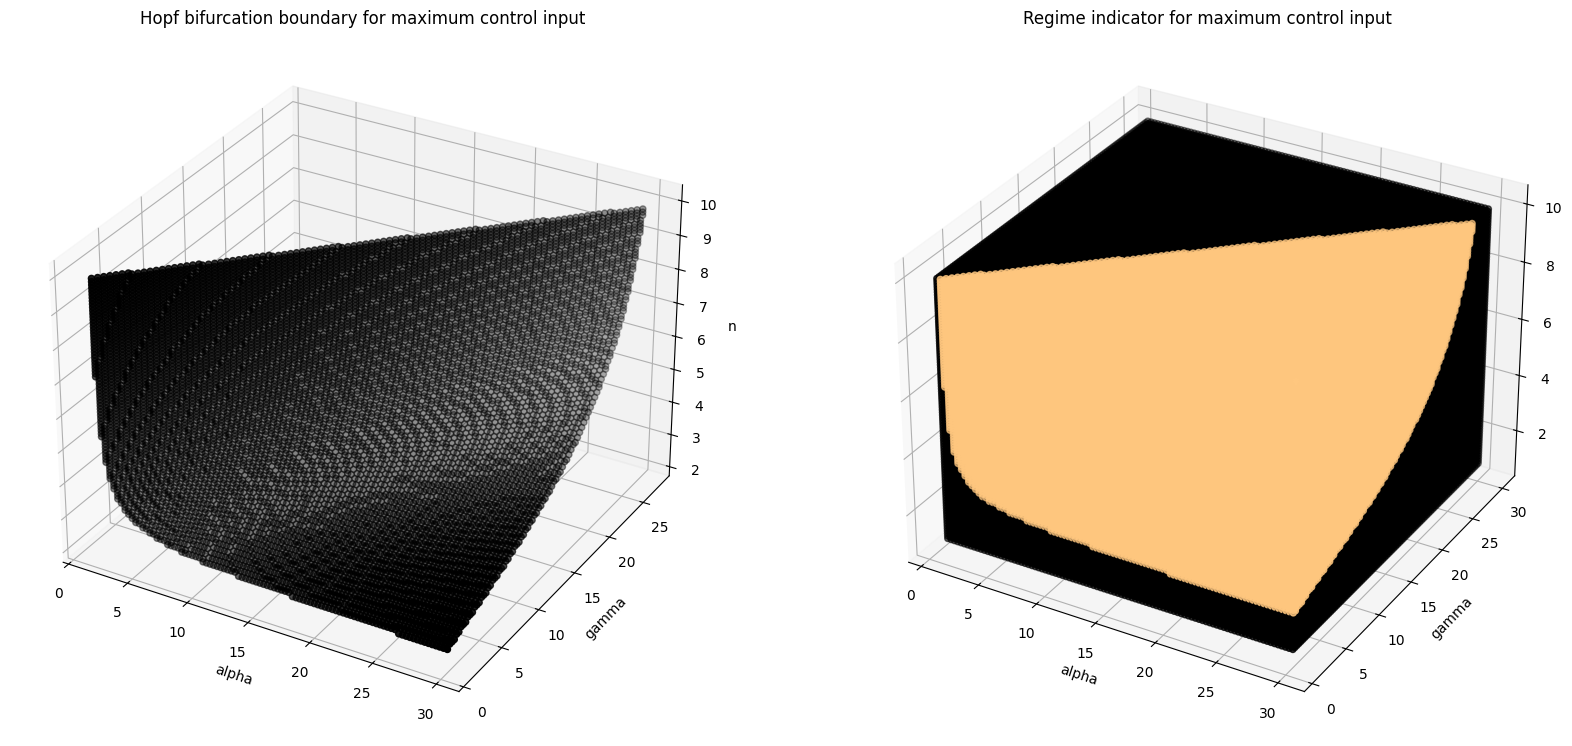

In [56]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
alpha_values = np.linspace(1, 30, 100)
r = np.zeros((100,100,100))
u = 1
for i, gamma in enumerate(gamma_values):
    for k, n in enumerate(n_values):
        for j, alpha in enumerate(alpha_values):
            model = Repressilator(alpha = alpha, gamma = gamma, n = n)
            r[j,i,k] = model.beta(u) - 2 * gamma

r_mask = np.zeros((100,100,100))
r_mask[r > 0] = 1
surface = np.zeros((100,100,100), dtype = bool)

for i in range(1,99):
    for j in range(1,99):
        for k in range(1,99):
            if r_mask[i,j,k] == 1:
                surface[i,j,k] = 1 - r_mask[i-1,j,k] * r_mask[i+1,j,k] * r_mask[i,j-1,k] * r_mask[i,j+1,k] * r_mask[i,j,k-1] * r_mask[i,j,k+1]



fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(1,2,1, projection='3d')
X,Y ,Z = np.meshgrid(alpha_values, gamma_values, n_values, indexing = 'ij')
ax.scatter(X[surface], Y[surface], Z[surface], color = 'black')
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Hopf bifurcation boundary for maximum control input')

ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(X,Y,Z, c=r_mask, cmap='copper')
ax2.set_xlabel('alpha')
ax2.set_ylabel('gamma')
ax2.set_zlabel('n')
ax2.set_title('Regime indicator for maximum control input')

plt.show()

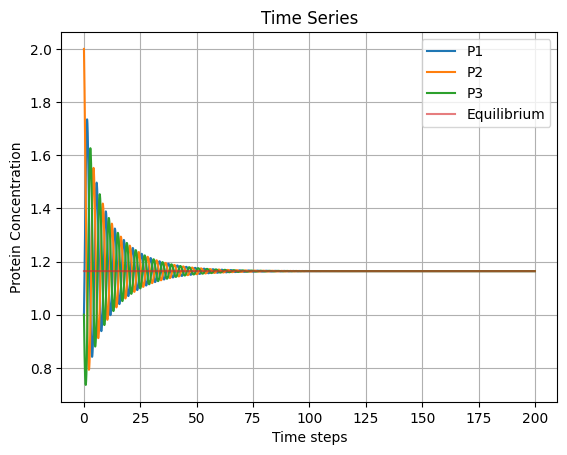

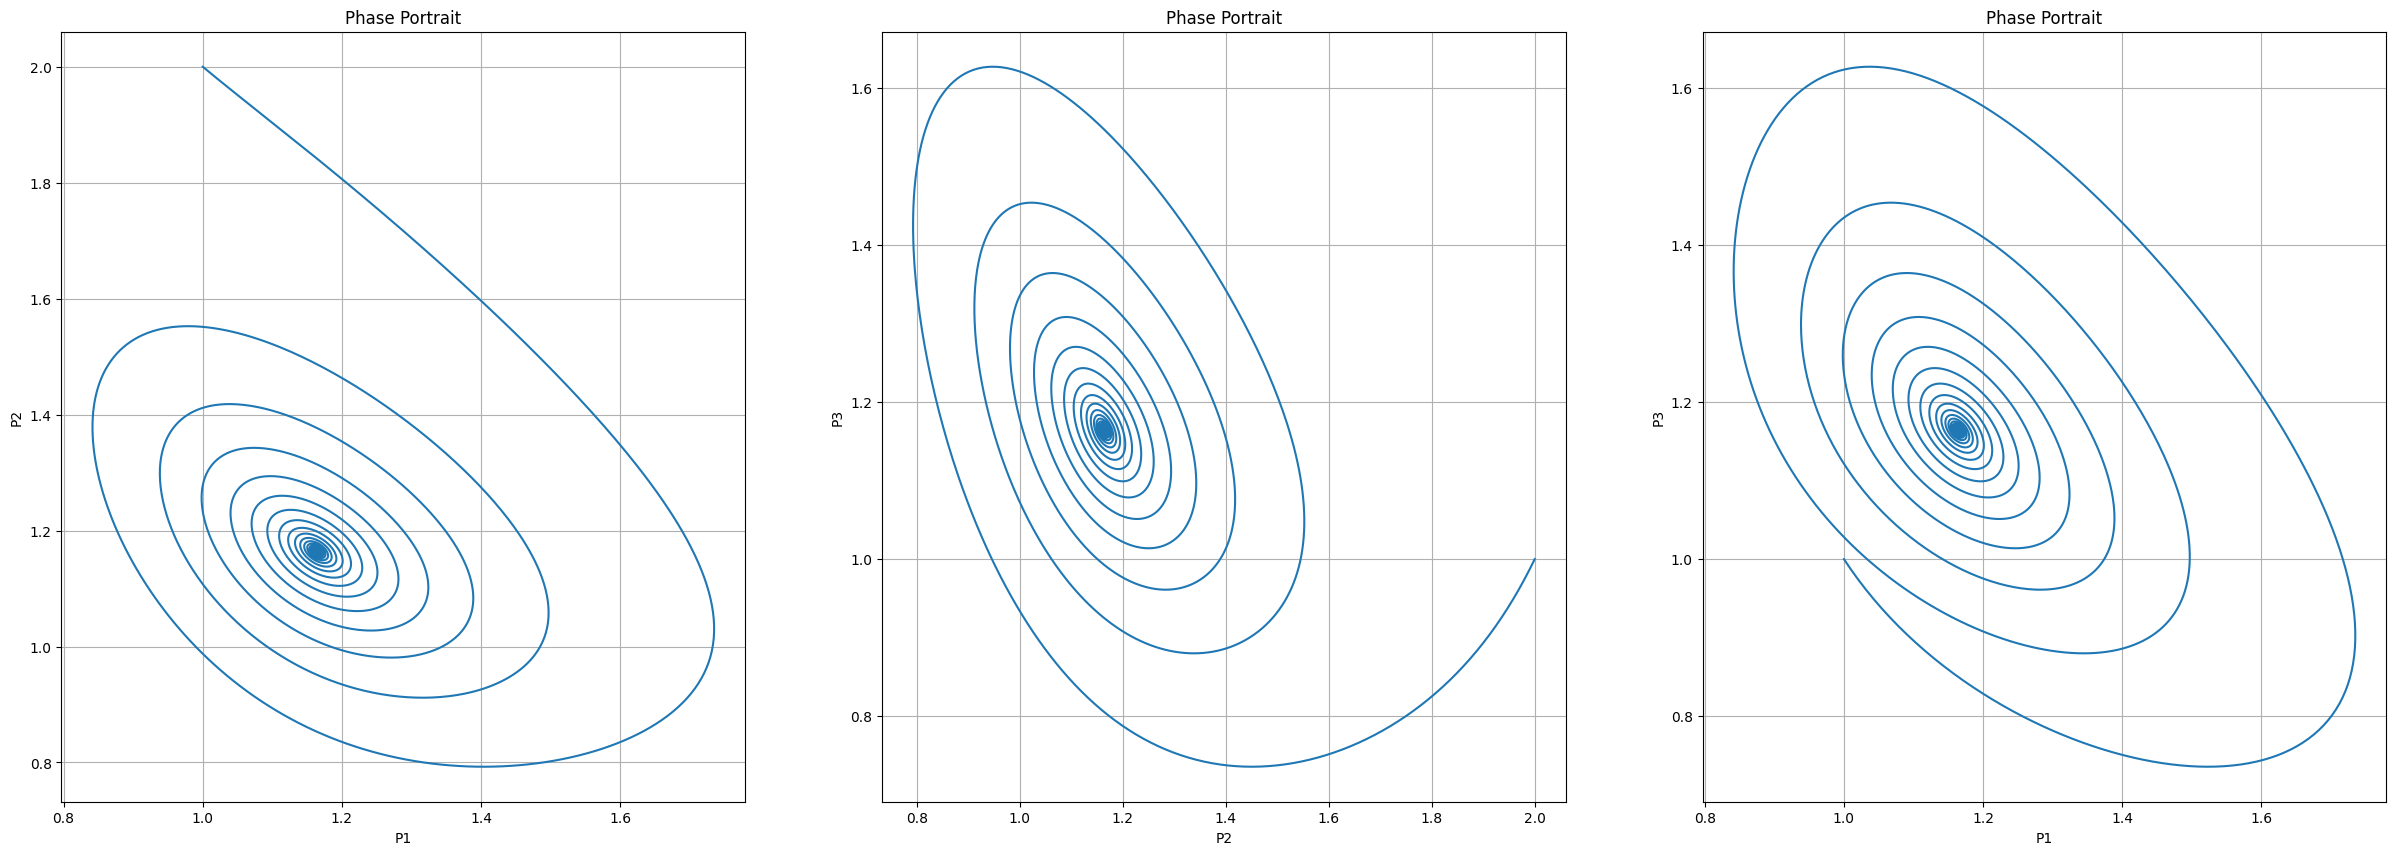

In [43]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.simulate(initial_state)
time_series(t, state, p_eq)
phase_portrait(state)

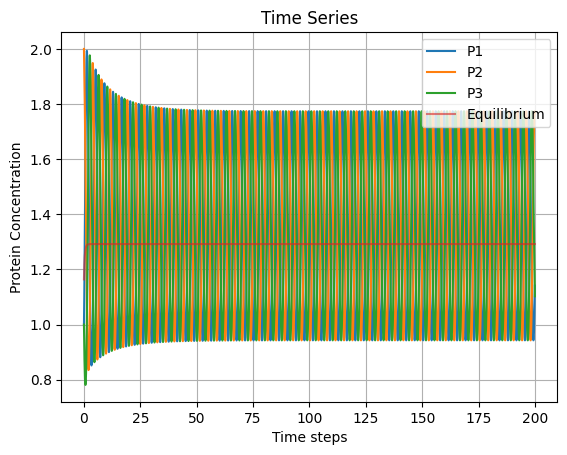

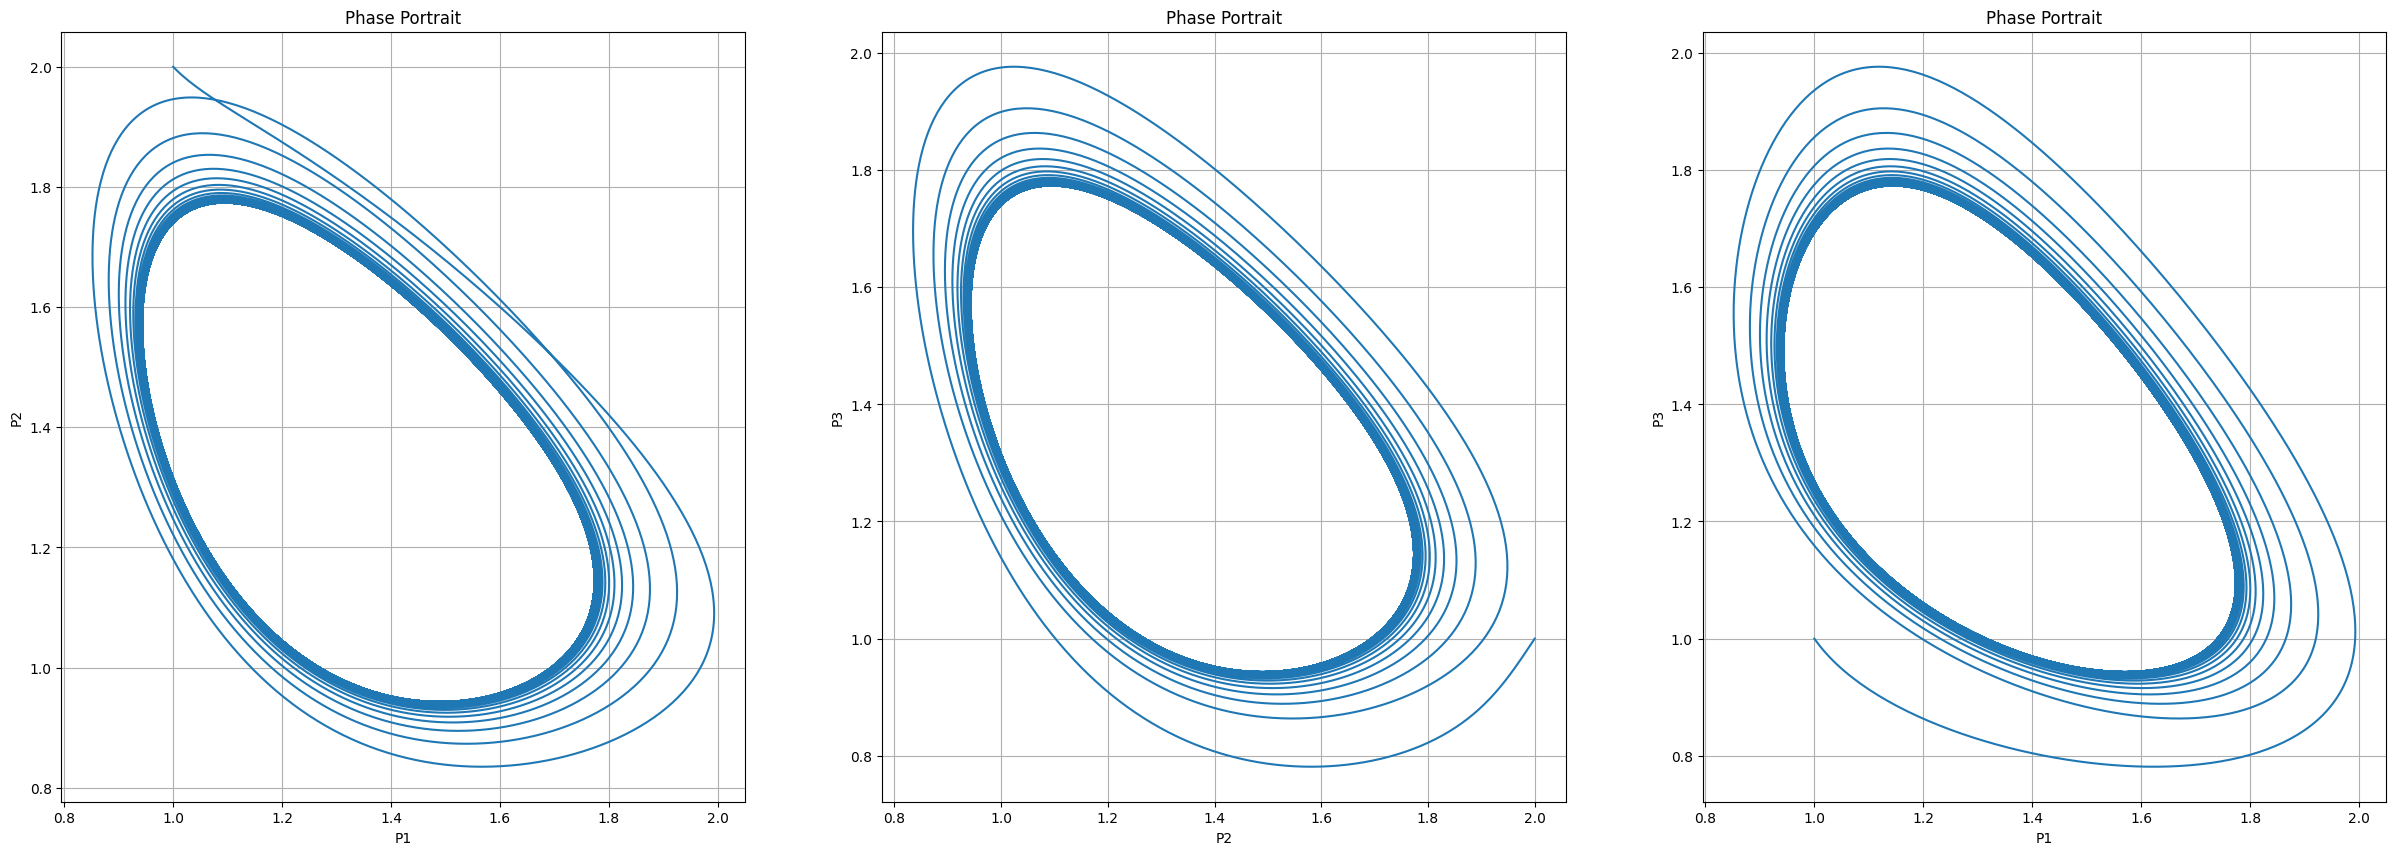

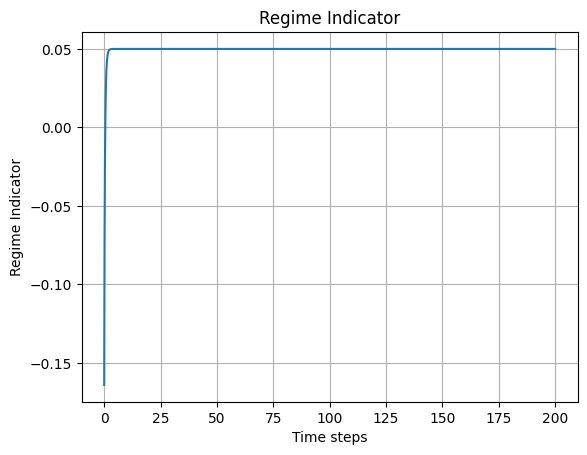

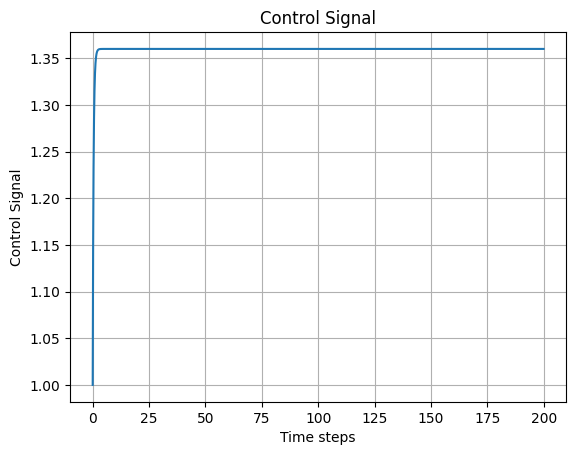

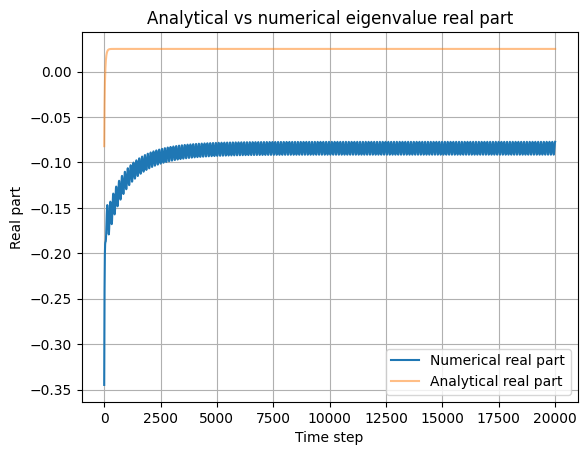

In [3]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
controller = PID(target_regime = 0.05)
t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)
control_signal(t, u)
hopf_comparison(model,state, u)

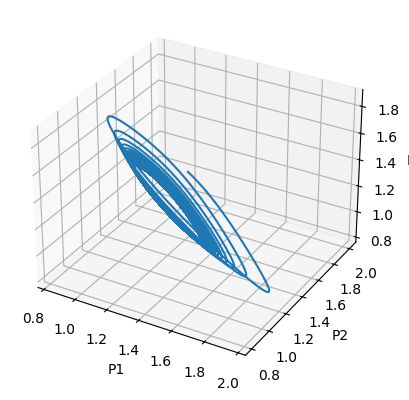

In [18]:
phase_portrait_3d(state)

100%|██████████| 10/10 [00:24<00:00,  2.43s/it]


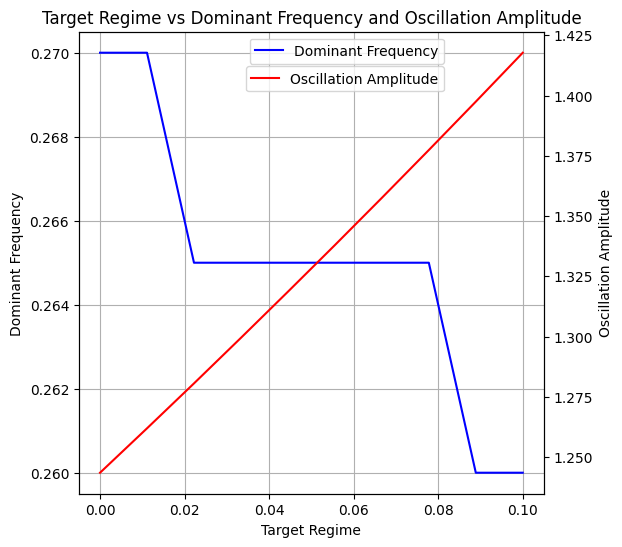

In [12]:
target_values = np.linspace(0, 0.1, 10)
dom_freqs = []
amps = []

for target in tqdm.tqdm(target_values):
    controller = PID(target_regime = target)
    t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
    dom_freq, freqs, spectrum = oscillation_freq(state[:,0], 0.01)
    amp = oscillation_amp(state[:,0])
    dom_freqs.append(dom_freq)
    amps.append(amp)

target_oscillation_plot(target_values, dom_freqs, amps)

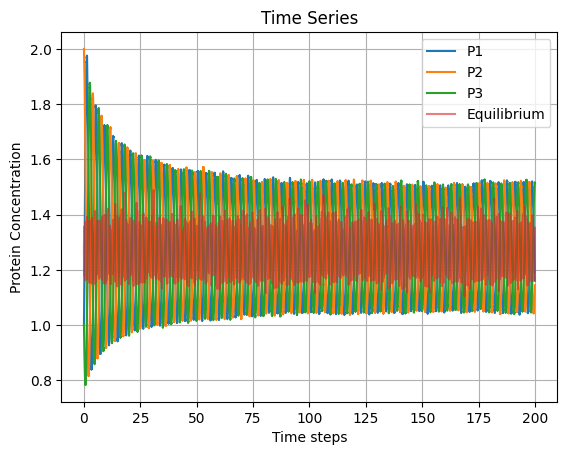

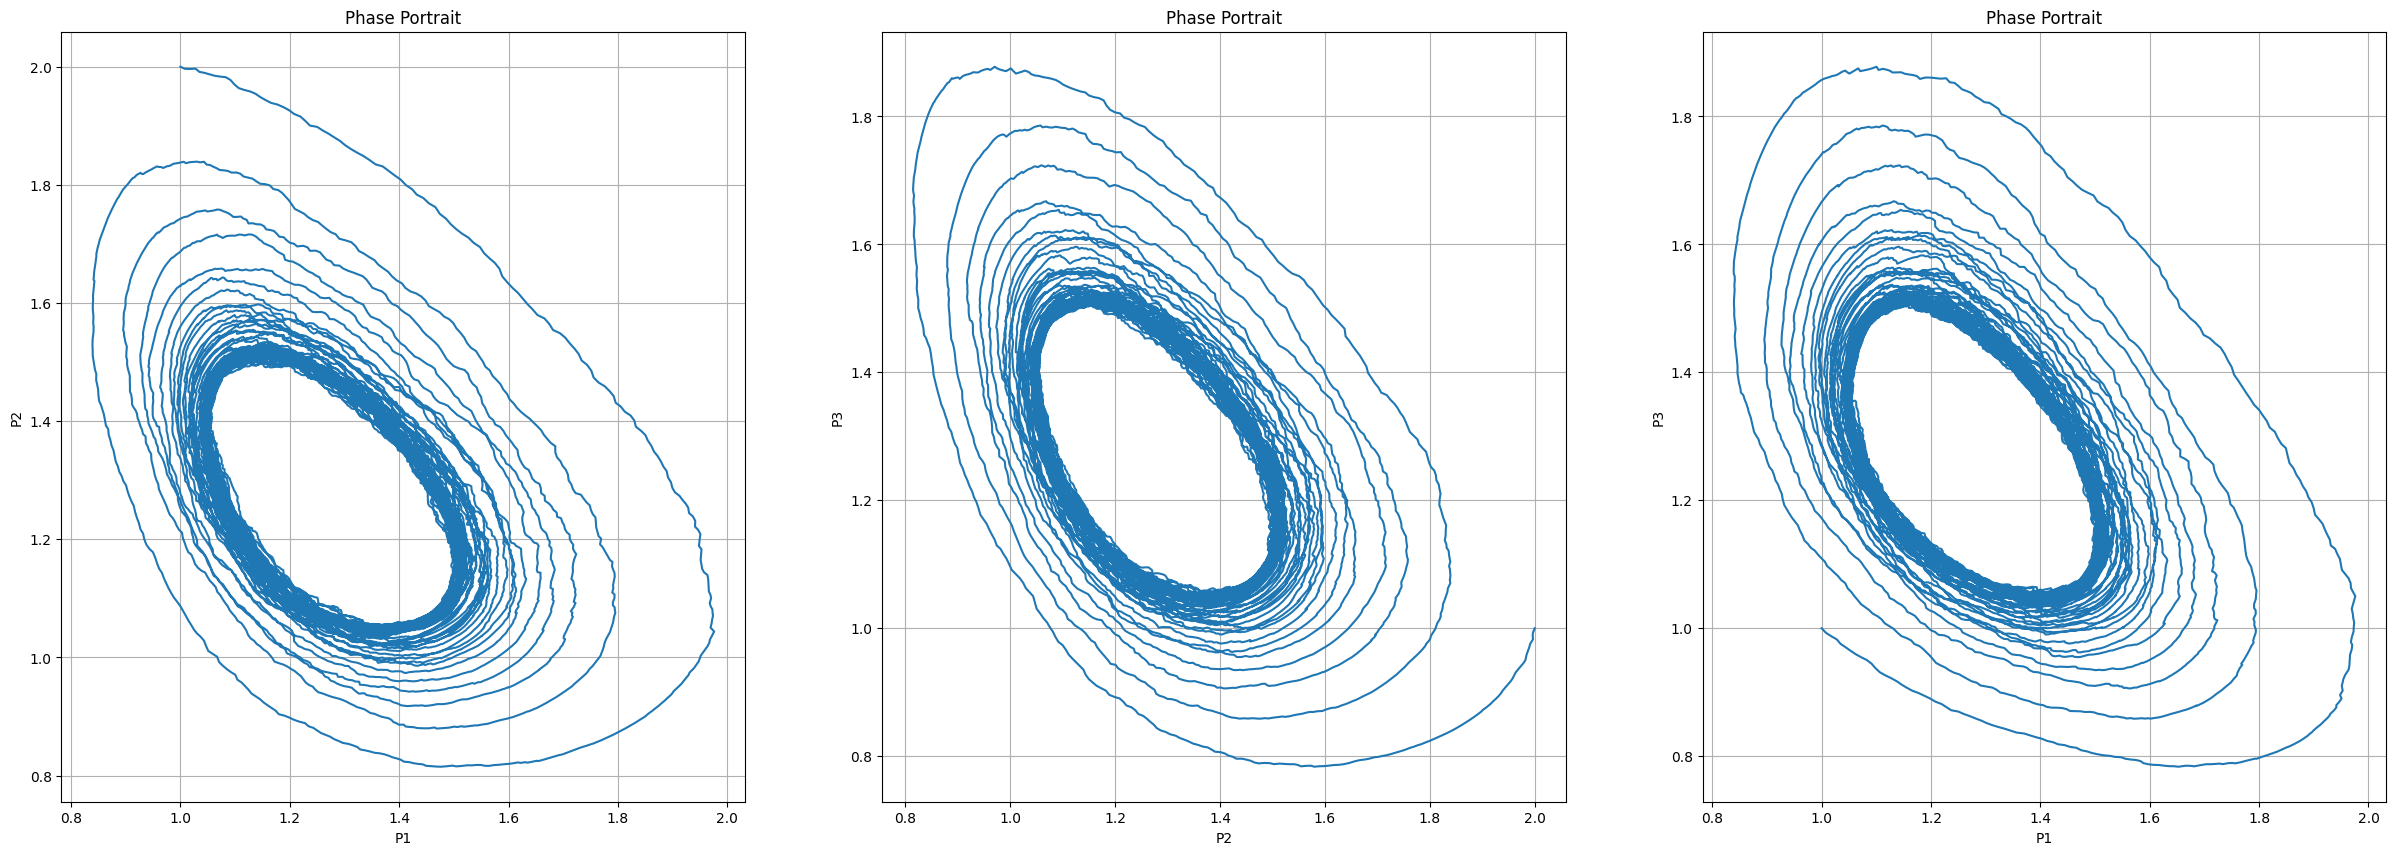

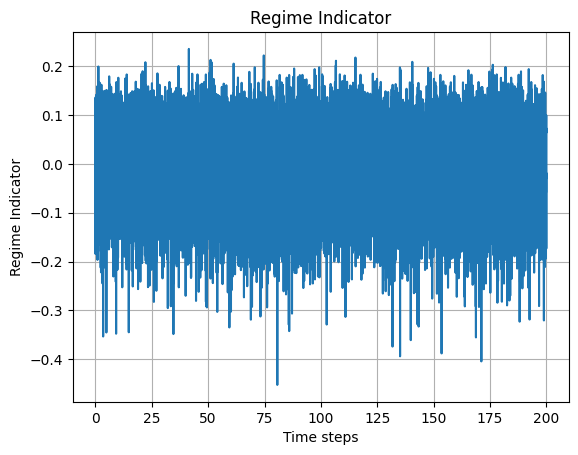

In [10]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
uc = fsolve(model.regime, 1)[0]
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.noisy_simulate(initial_state, u0 = uc)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)

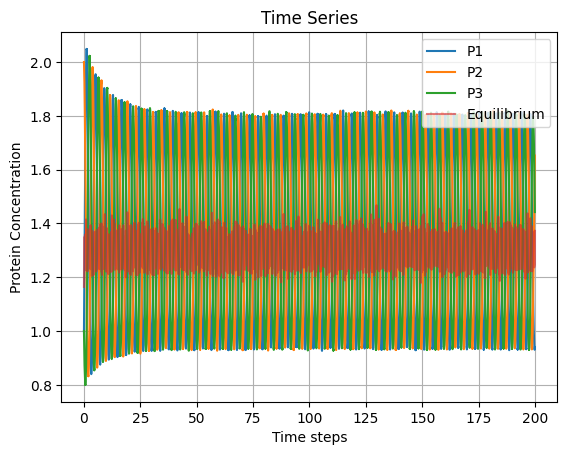

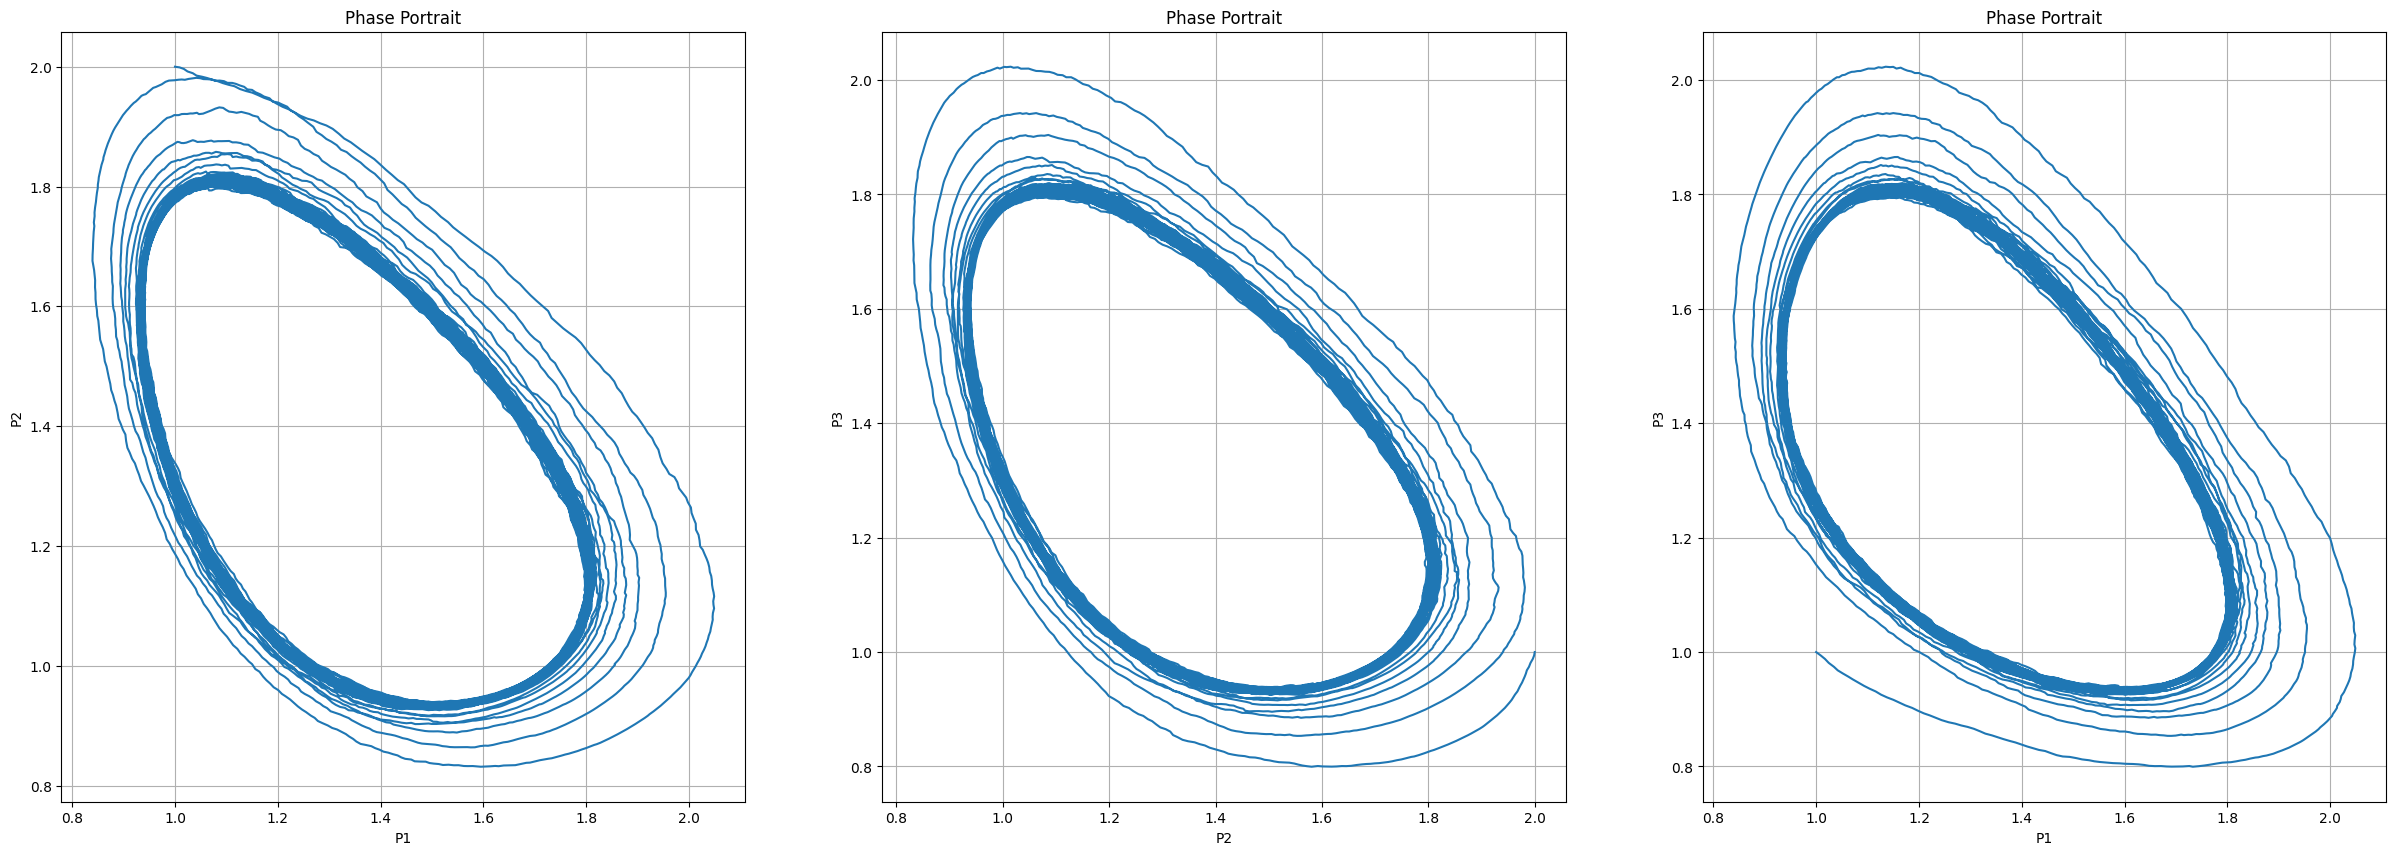

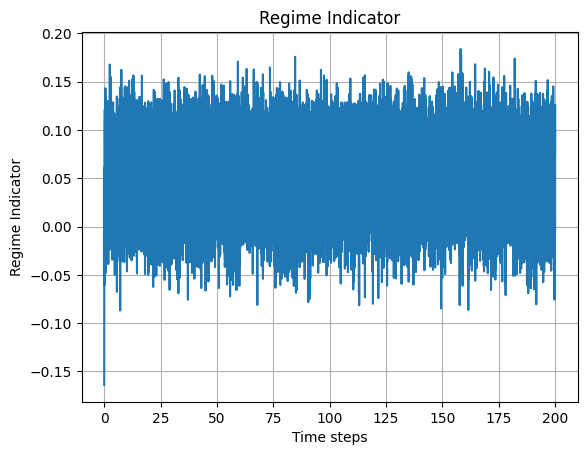

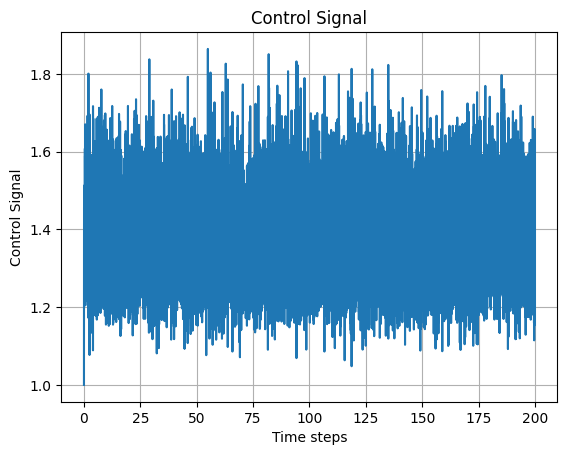

In [8]:
model = Repressilator(alpha = 3, gamma = 1, n = 3)
controller = PID(kp = 0.3, ki = 0.1, kd = 0.01, target_regime = 0.05)
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.noisy_simulate(initial_state,control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)
control_signal(t, u)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model.repressilator import Repressilator, Repressilator_one_control
from model.pid import PID
from analysis.signal_analysis import *
from visualization.plotter import *
import tqdm
from scipy.optimize import fsolve, minimize_scalar
from scipy.stats import qmc
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier


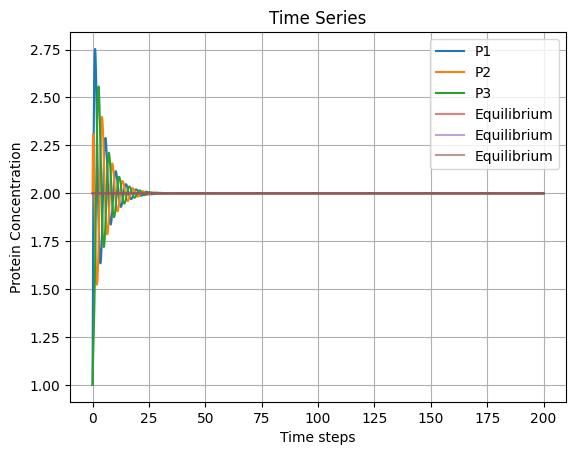

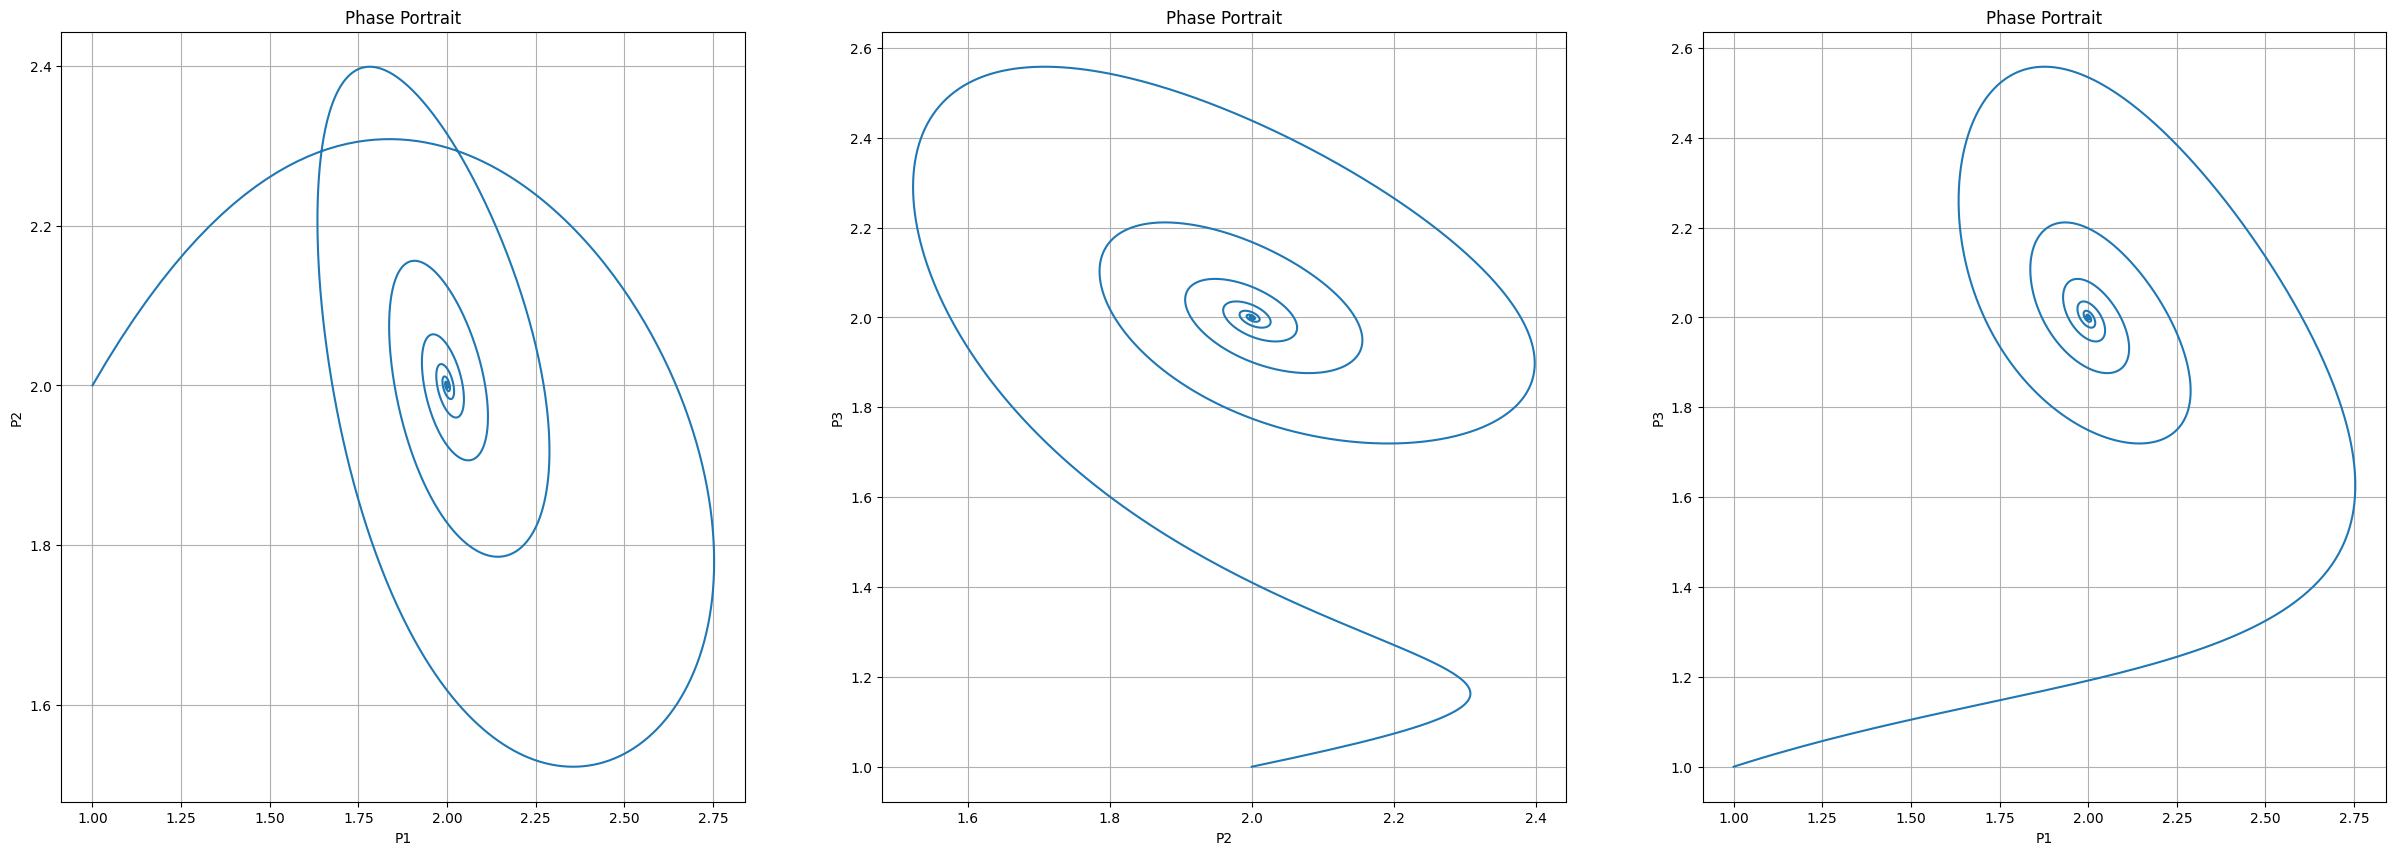

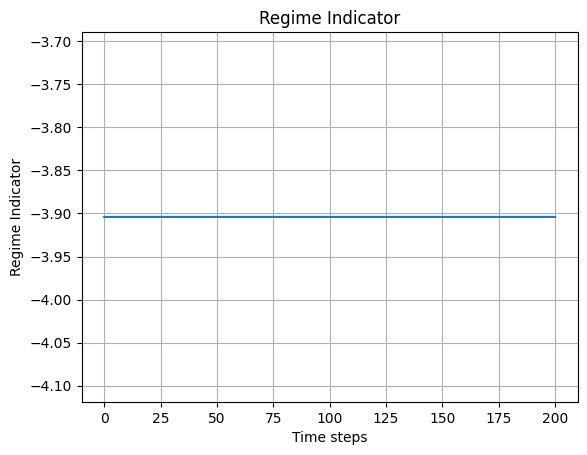

In [2]:
model = Repressilator_one_control()
initial_state = np.array([1, 2, 1])
t, state, u, r, p_eq = model.simulate(initial_state)
time_series(t, state, p_eq)
phase_portrait(state)
regime_indicator(t, r)

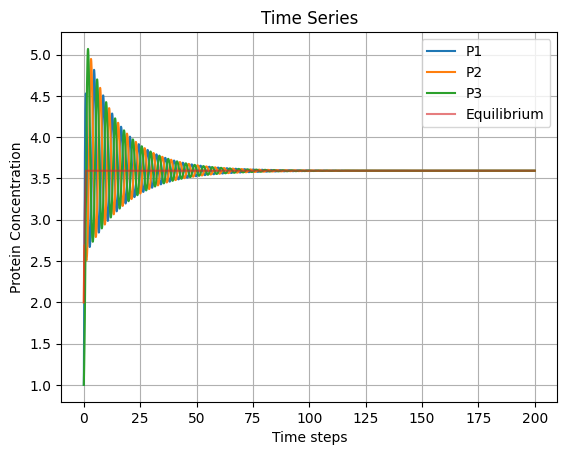

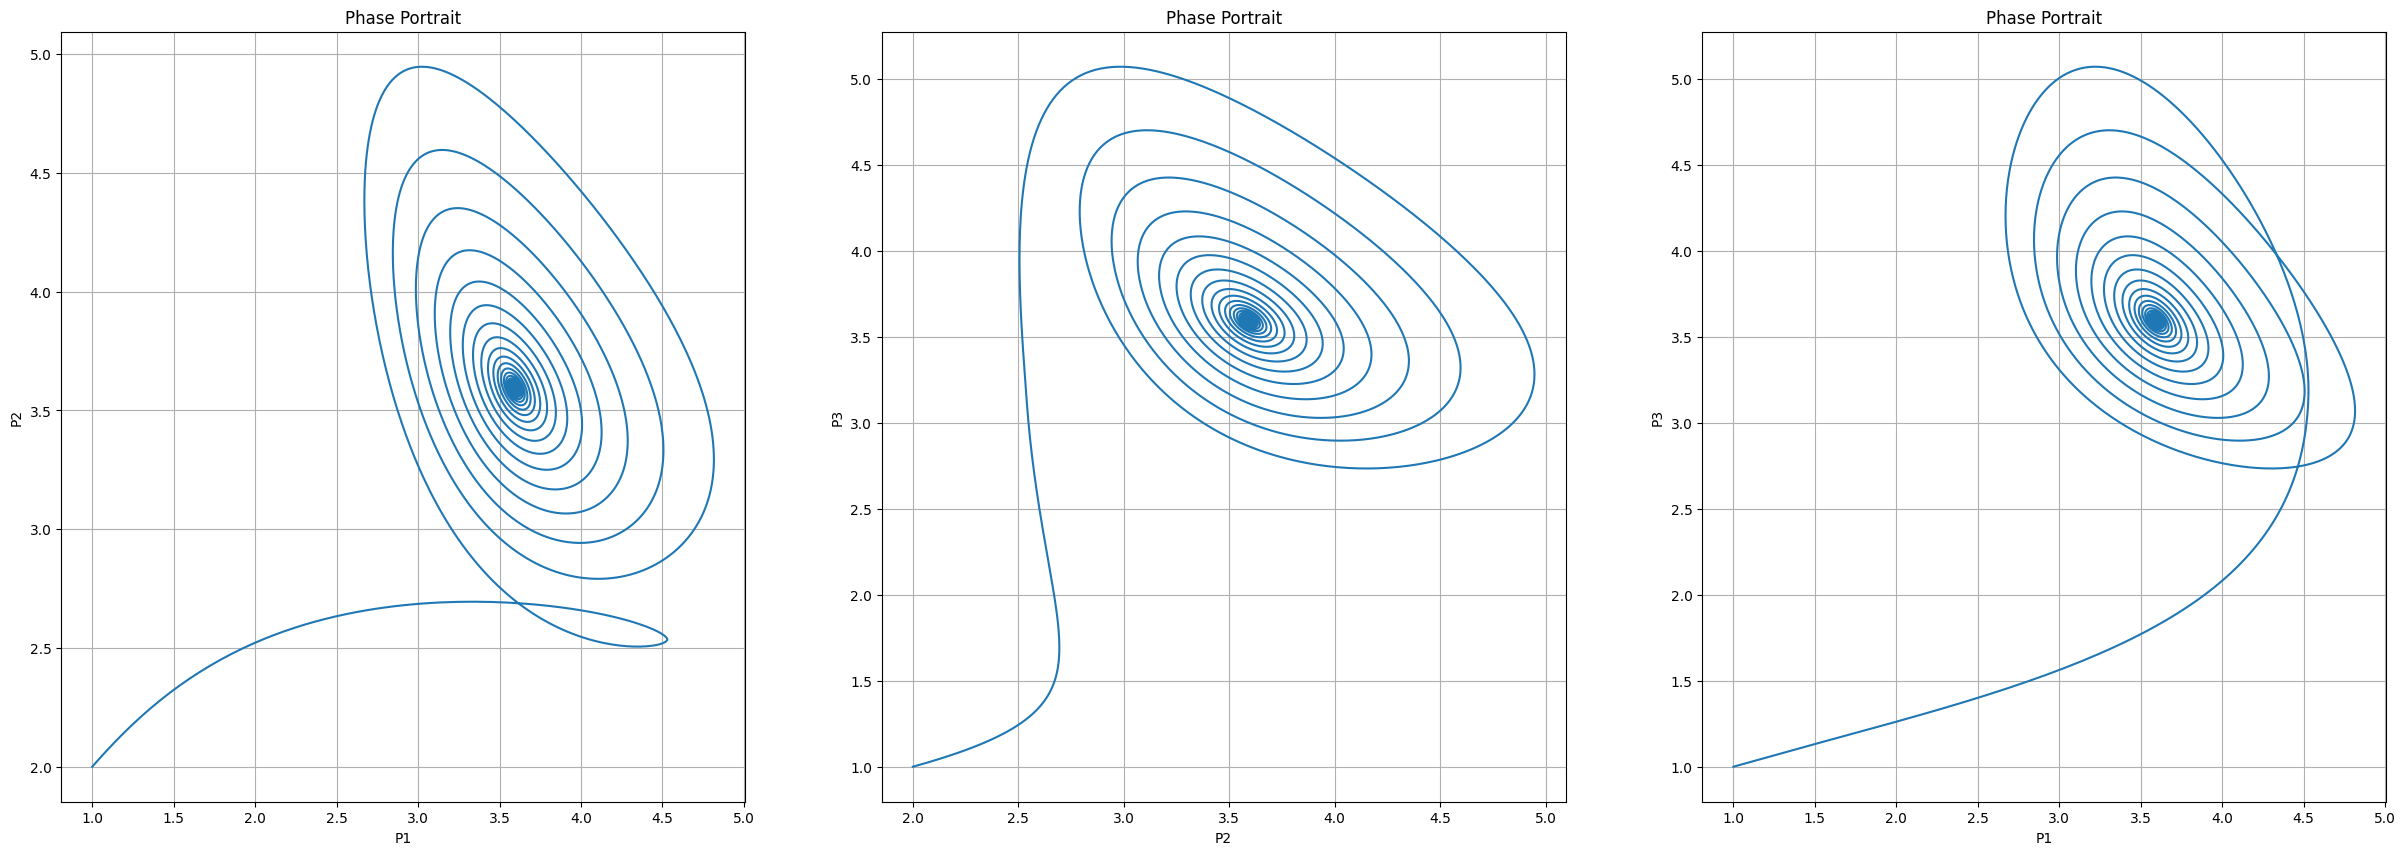

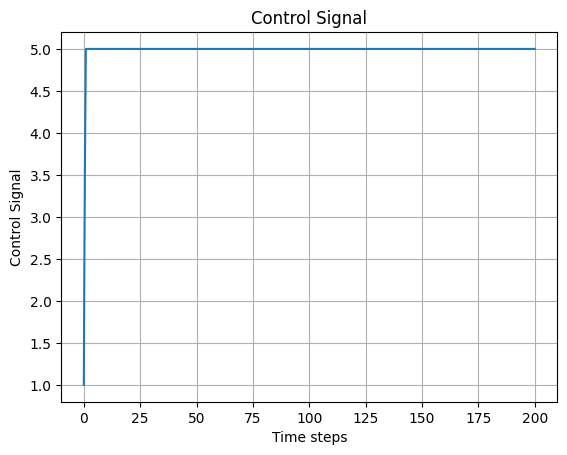

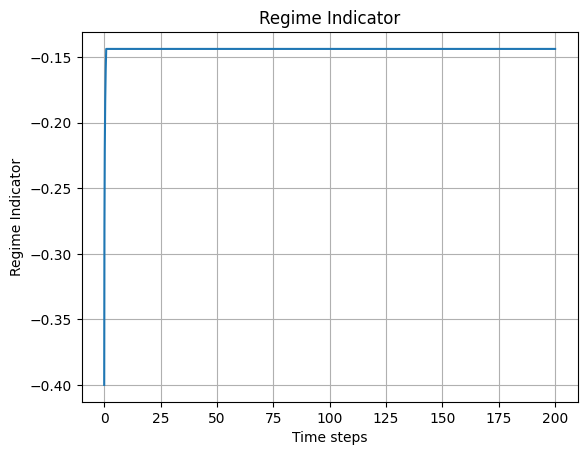

In [16]:
controller = PID(kp = 0.2, ki = 0, kd = 0, target_regime = 0.02)
model = Repressilator()

t, state, u, r, p_eq = model.simulate(initial_state, control = controller, u0 = 1)
time_series(t, state, p_eq)
phase_portrait(state)
control_signal(t, u)
regime_indicator(t, r)

In [2]:
def is_controllable(model):
    if model.regime(1) > 0:
        return False
    
    def objective(u):
        return -model.regime(u)
    
    res = minimize_scalar(objective, bounds = (0.2, 5), method = 'bounded')
    R_max = -res.fun
    controllable = R_max > 0

    return controllable

In [3]:



N = 30000
sampler = qmc.LatinHypercube(d = 3)
X = sampler.random(N)

X[:, 0] = 1 + X[:, 0] * 29
X[:, 1] = 1 + X[:, 1] * 29
X[:, 2] = 1 + X[:, 2] * 9

y = np.zeros(N, dtype = int)
for i, (alpha, gamma, n) in enumerate(X):
    model = Repressilator_one_control(alpha = alpha, gamma = gamma, n = n)

    if is_controllable(model):
        y[i] = 1

new_points = X[y == 1] 
new_points = new_points + np.random.randn(new_points.shape[0], 3) * 0.05
new_y = np.zeros(new_points.shape[0], dtype = int)
for i, (alpha, gamma, n) in enumerate(new_points):
    model = Repressilator_one_control(alpha = alpha, gamma = gamma, n = n)

    if is_controllable(model):
        new_y[i] = 1

X = np.vstack([X, new_points])
y = np.hstack([y, new_y])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=10, weights = 'distance')
knn.fit(X_scaled, y)

/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:130: RuntimeWarning: invalid value encountered in scalar power
  self.alpha / (1 + P1**self.n) - self.gamma * P2,
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:134: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_point = fsolve(equations, [1, 1, 1])
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:134: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  eq_point = fsolve(equations, [1, 1, 1])
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:131: RuntimeWarning: invalid value encountered in scalar power
  u * self.alpha / (1 + P2**self.n) - self.gamma * P3


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


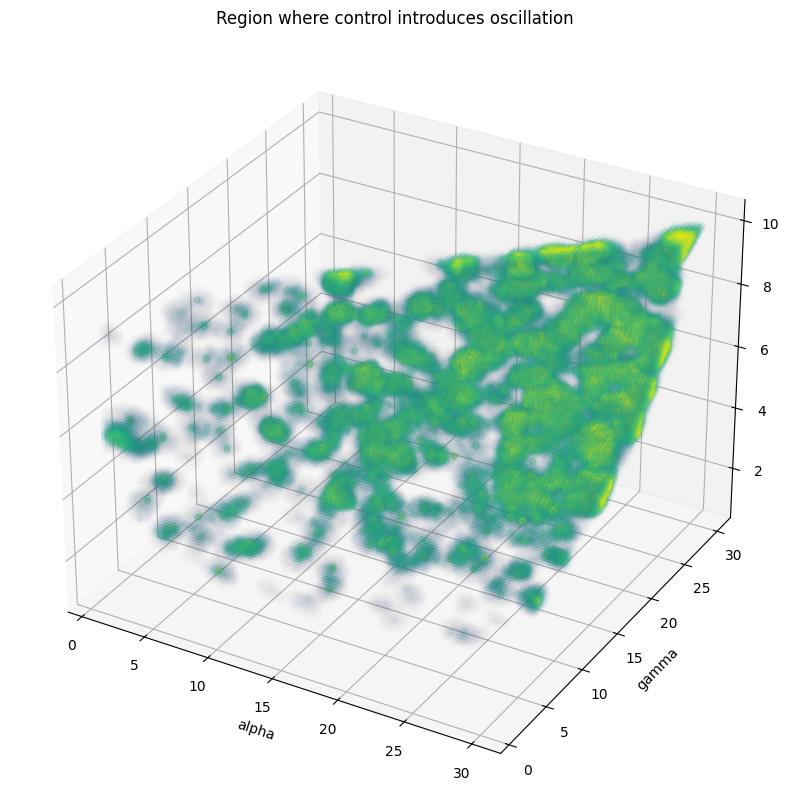

In [4]:
A, G, N = np.meshgrid(np.linspace(1, 30, 100), np.linspace(1, 30, 100), np.linspace(1, 10, 100), indexing = 'ij')
new_params = np.stack([A.flatten(), G.flatten(), N.flatten()], axis = 1)
new_params = scaler.transform(new_params)
p = knn.predict_proba(new_params)[:, 1].reshape(A.shape)
#p = p.reshape(100,100,100)
sm = plt.cm.ScalarMappable(cmap = 'viridis', norm = plt.Normalize(vmin = 0, vmax = 1))
rgba = sm.to_rgba(p.flatten())
rgba[:, 3] = 1 / (1 + np.exp(- 10 *(p.flatten() - 0.7)))
fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(A, G, N, c=rgba)
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Region where control introduces oscillation')

plt.show()

In [5]:
p = knn.predict_proba(new_params)[:, 1]
N_boundary = 2000
boundary_id = np.argsort(np.abs(p-0.5))[:N_boundary]
boundary_points = new_params[boundary_id]
boundary_points = boundary_points + np.random.randn(boundary_points.shape[0], 3) * 0.05
boundary_y = np.zeros(boundary_points.shape[0], dtype = int)
for i, (alpha, gamma, n) in enumerate(boundary_points):
    model = Repressilator_one_control(alpha = alpha, gamma = gamma, n = n)

    if is_controllable(model):
        boundary_y[i] = 1

X = np.vstack([X, boundary_points])
y = np.hstack([y, boundary_y])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

knn = KNeighborsClassifier(n_neighbors=10, weights = 'distance')
knn.fit(X_scaled, y)

/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:129: RuntimeWarning: invalid value encountered in scalar power
  self.alpha / (1 + P3**self.n) - self.gamma * P1,
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:130: RuntimeWarning: invalid value encountered in scalar power
  self.alpha / (1 + P1**self.n) - self.gamma * P2,
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:131: RuntimeWarning: invalid value encountered in scalar power
  u * self.alpha / (1 + P2**self.n) - self.gamma * P3
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:134: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  eq_point = fsolve(equations, [1, 1, 1])
/Users/rayenezanina/Desktop/Project/repressillator control/model/repressilator.py:134: RuntimeWarning: The iteration is not making good progress, as measured 

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


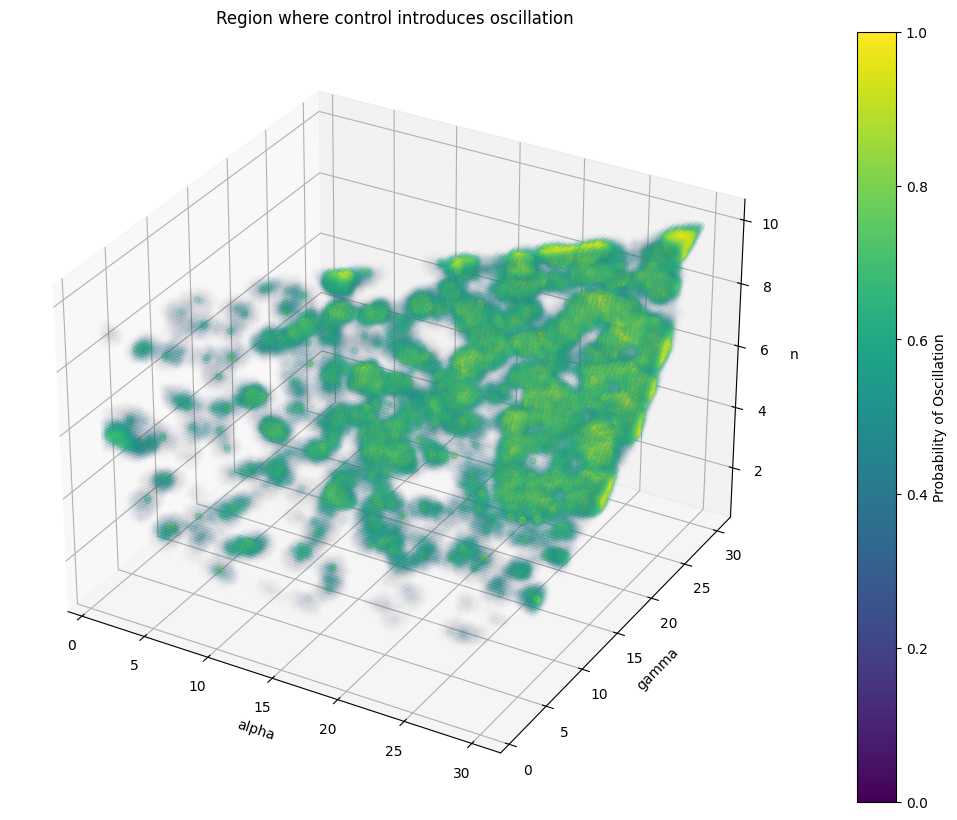

In [6]:
A, G, N = np.meshgrid(np.linspace(1, 30, 100), np.linspace(1, 30, 100), np.linspace(1, 10, 100), indexing = 'ij')
new_params = np.stack([A.flatten(), G.flatten(), N.flatten()], axis = 1)
new_params = scaler.transform(new_params)
p = knn.predict_proba(new_params)[:, 1].reshape(A.shape)
#p = p.reshape(100,100,100)
sm = plt.cm.ScalarMappable(cmap = 'viridis', norm = plt.Normalize(vmin = 0, vmax = 1))
rgba = sm.to_rgba(p.flatten())
rgba[:, 3] = 1 / (1 + np.exp(- 10 *(p.flatten() - 0.7)))
fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(A, G, N, c=rgba)
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Region where control introduces oscillation')

plt.colorbar(sm, ax = ax, label = 'Probability of Oscillation')

100it [00:31,  3.19it/s]


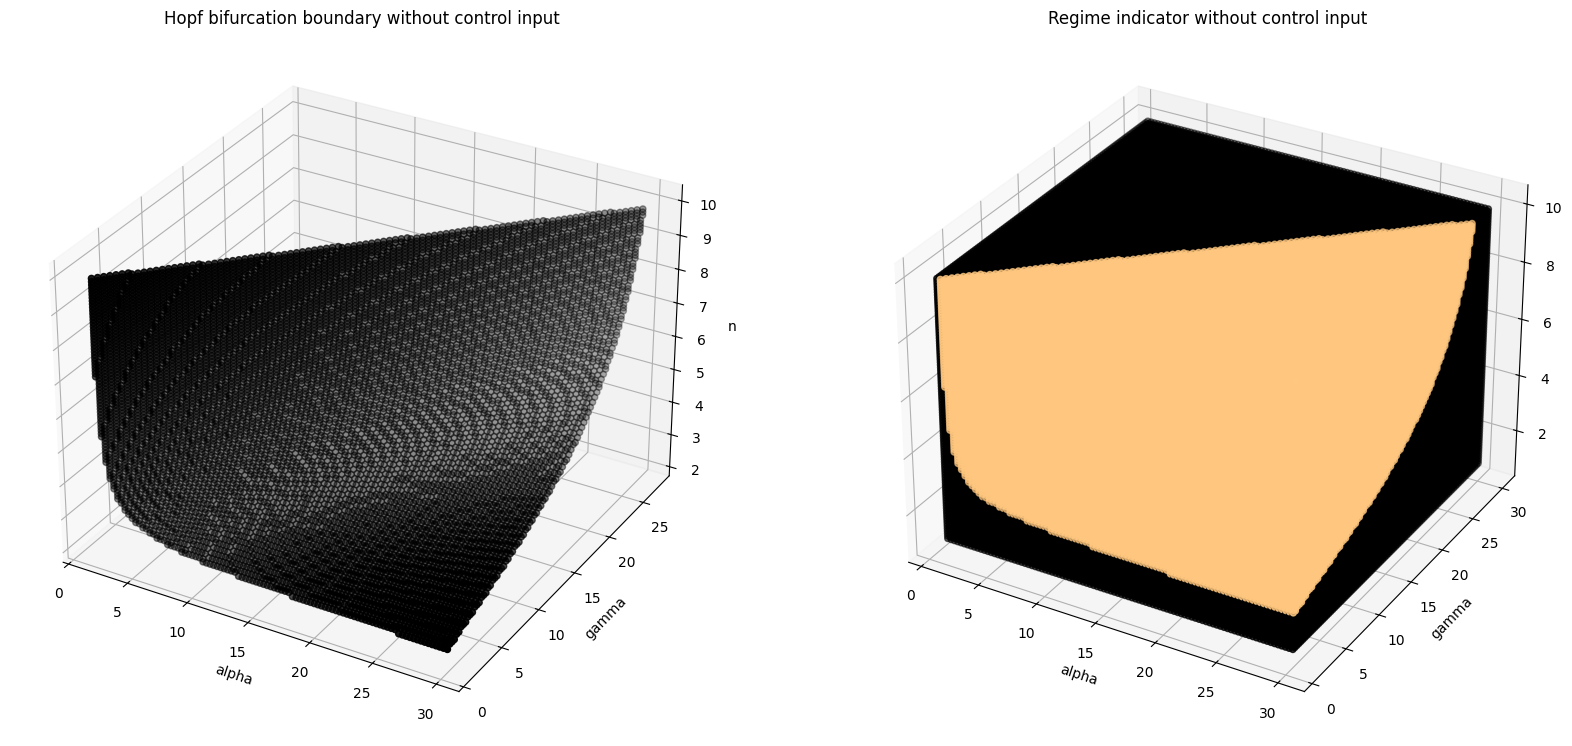

In [17]:
gamma_values = np.linspace(1, 30, 100)
n_values = np.linspace(1, 10, 100)
alpha_values = np.linspace(1, 30, 100)
r = np.zeros((100,100,100))
u = 1
for i, gamma in tqdm.tqdm(enumerate(gamma_values)):
    for k, n in enumerate(n_values):
        for j, alpha in enumerate(alpha_values):
            model = Repressilator_one_control(alpha = alpha, gamma = gamma, n = n)
            r[j,i,k] = model.regime(1) > 0

r_mask = np.zeros((100,100,100))
r_mask = r
surface = np.zeros((100,100,100), dtype = bool)

for i in range(1,99):
    for j in range(1,99):
        for k in range(1,99):
            if r_mask[i,j,k] == 1:
                surface[i,j,k] = 1 - r_mask[i-1,j,k] * r_mask[i+1,j,k] * r_mask[i,j-1,k] * r_mask[i,j+1,k] * r_mask[i,j,k-1] * r_mask[i,j,k+1]



fig = plt.figure(figsize = (20, 10))
ax = fig.add_subplot(1,2,1, projection='3d')
X,Y ,Z = np.meshgrid(alpha_values, gamma_values, n_values, indexing = 'ij')
ax.scatter(X[surface], Y[surface], Z[surface], color = 'black')
ax.set_xlabel('alpha')
ax.set_ylabel('gamma')
ax.set_zlabel('n')
ax.set_title('Hopf bifurcation boundary without control input')

ax2 = fig.add_subplot(1,2,2, projection='3d')
ax2.scatter(X,Y,Z, c=r_mask, cmap='copper')
ax2.set_xlabel('alpha')
ax2.set_ylabel('gamma')
ax2.set_zlabel('n')
ax2.set_title('Regime indicator without control input')

plt.show()

100%|██████████| 500/500 [02:24<00:00,  3.45it/s]


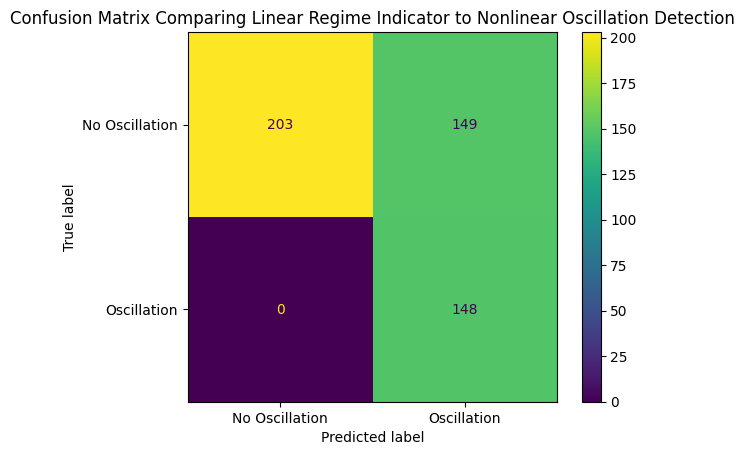

In [78]:
from scipy.signal import find_peaks
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def oscillates(signal, threshold = 0.1):
    peaks, _ = find_peaks(signal)
    if len(peaks) < 5:
        return False
    amp = np.max(signal) - np.min(signal)
    return amp > threshold

lin_preds = []
nonlin_preds = []
random_points = np.random.rand(500, 3)
random_points[:, 0] = 1 + random_points[:, 0] * 29
random_points[:, 1] = 1 + random_points[:, 1] * 29
random_points[:, 2] = 1 + random_points[:, 2] * 9
for alpha, gamma, n in tqdm.tqdm(random_points):
    model = Repressilator_one_control(alpha = alpha, gamma = gamma, n = n)
    t, state, _, _, _ = model.simulate(initial_state, u0 = 1, t=50)
    linear = model.regime(1) > 0
    nonlinear = oscillates(state[:,0])
    lin_preds.append(linear)
    nonlin_preds.append(nonlinear)

cm = confusion_matrix(lin_preds, nonlin_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Oscillation', 'Oscillation'])
disp.plot()
plt.title('Confusion Matrix Comparing Linear Regime Indicator to Nonlinear Oscillation Detection')
plt.show()

In [111]:
tp, fp, tn, fn = cm.flatten()
print(f"Precision: {tp / (tp + fp):.2f}")
print(f"Recall: {tp / (tp + fn):.2f}")
print(f"F1 Score: {2 * tp / (2 * tp + fp + fn):.2f}")

Precision: 0.58
Recall: 0.58
F1 Score: 0.58


Parameters: alpha = 18.17, gamma = 1.84, n = 6.66


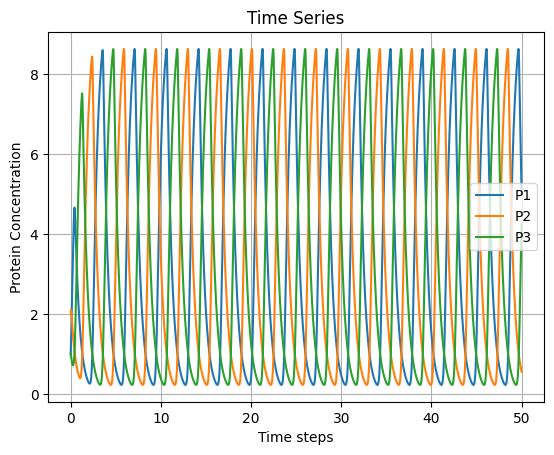

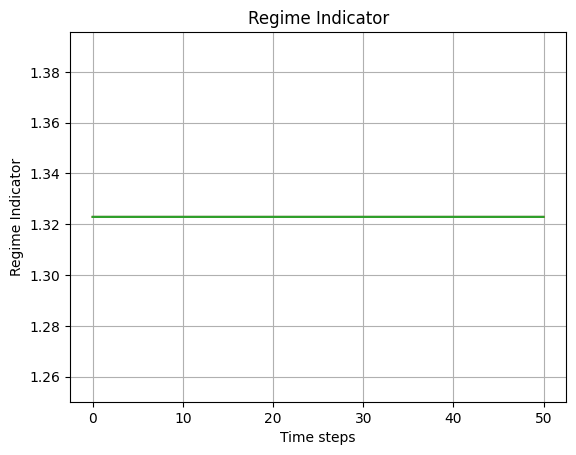

In [109]:
while True:
    i = np.random.randint(0, len(random_points))
    if np.equal([lin_preds[i], nonlin_preds[i]], [True, True]).all():
        point = random_points[i]
        break

model = Repressilator_one_control(alpha = point[0], gamma = point[1], n = point[2])
t, state, _, _, r = model.simulate(initial_state, u0 = 1, t=50)
print(f"Parameters: alpha = {point[0]:.2f}, gamma = {point[1]:.2f}, n = {point[2]:.2f}")
time_series(t, state)
regime_indicator(t, r)

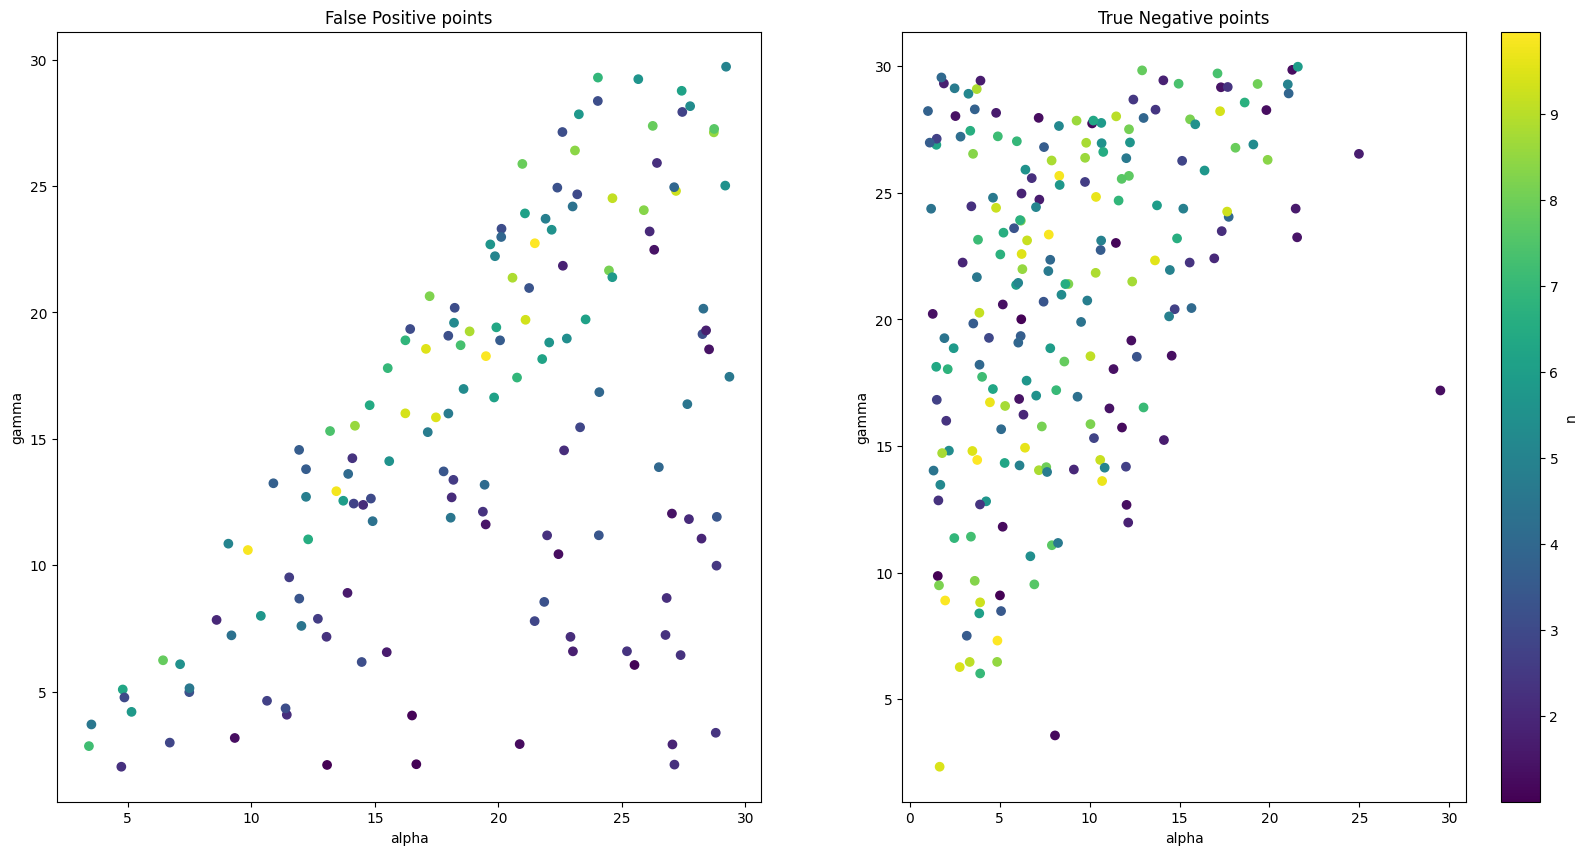

In [80]:
fp = []
tn = []
for i, j in enumerate(np.vstack([lin_preds, nonlin_preds]).T):
    if np.equal(j, [False, True]).all():
        fp.append(random_points[i])
    elif np.equal(j, [False, False]).all():
        tn.append(random_points[i])

fp = np.array(fp)
tn = np.array(tn)
plt.figure(figsize = (20, 10))
plt.subplot(1, 2, 1)
plt.scatter(fp[:,0], fp[:,1], c = fp[:,2], cmap = 'viridis')
plt.xlabel('alpha')
plt.ylabel('gamma')
plt.title('False Positive points')
plt.subplot(1, 2, 2)
plt.scatter(tn[:,0], tn[:,1], c = tn[:,2], cmap = 'viridis')
plt.xlabel('alpha')
plt.ylabel('gamma')
plt.title('True Negative points')
plt.colorbar(label = 'n')
plt.show()

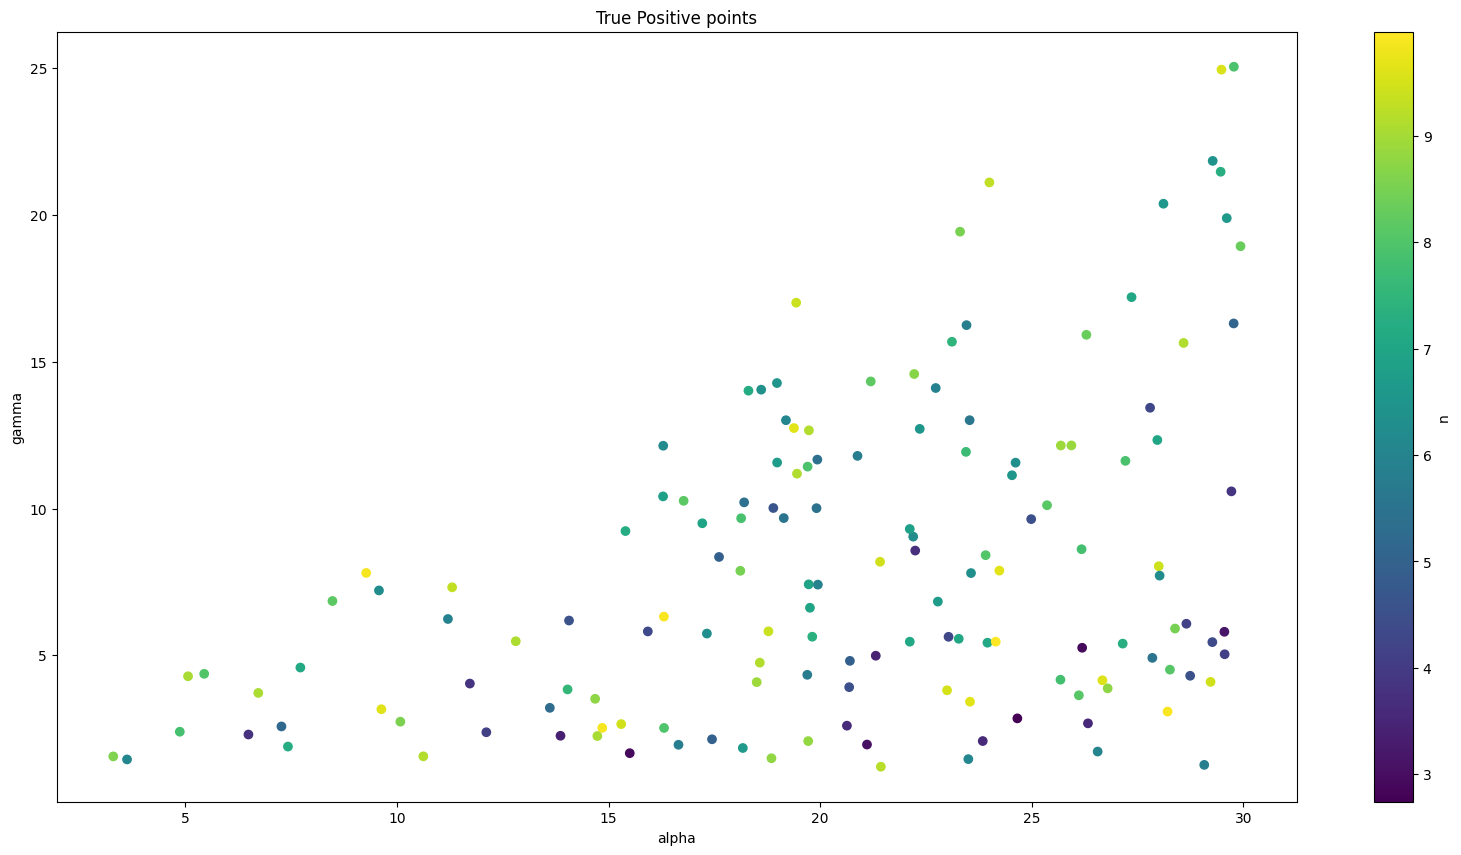

In [112]:
tp = []
for i, j in enumerate(np.vstack([lin_preds, nonlin_preds]).T):
    if np.equal(j, [True, True]).all():
        tp.append(random_points[i])

tp = np.array(tp)
plt.figure(figsize = (20, 10))
plt.scatter(tp[:,0], tp[:,1], c = tp[:,2], cmap = 'viridis')
plt.xlabel('alpha')
plt.ylabel('gamma')
plt.title('True Positive points')
plt.colorbar(label = 'n')
plt.show()

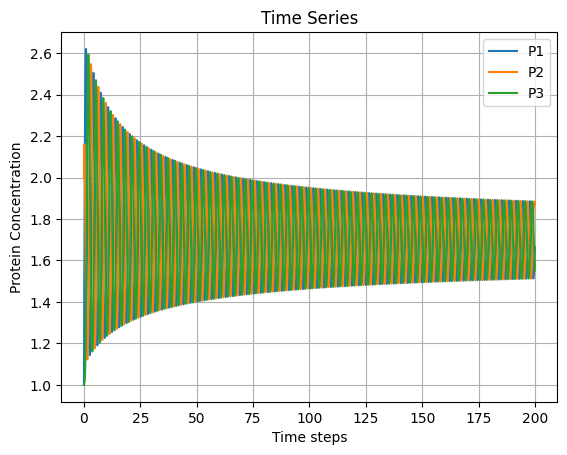

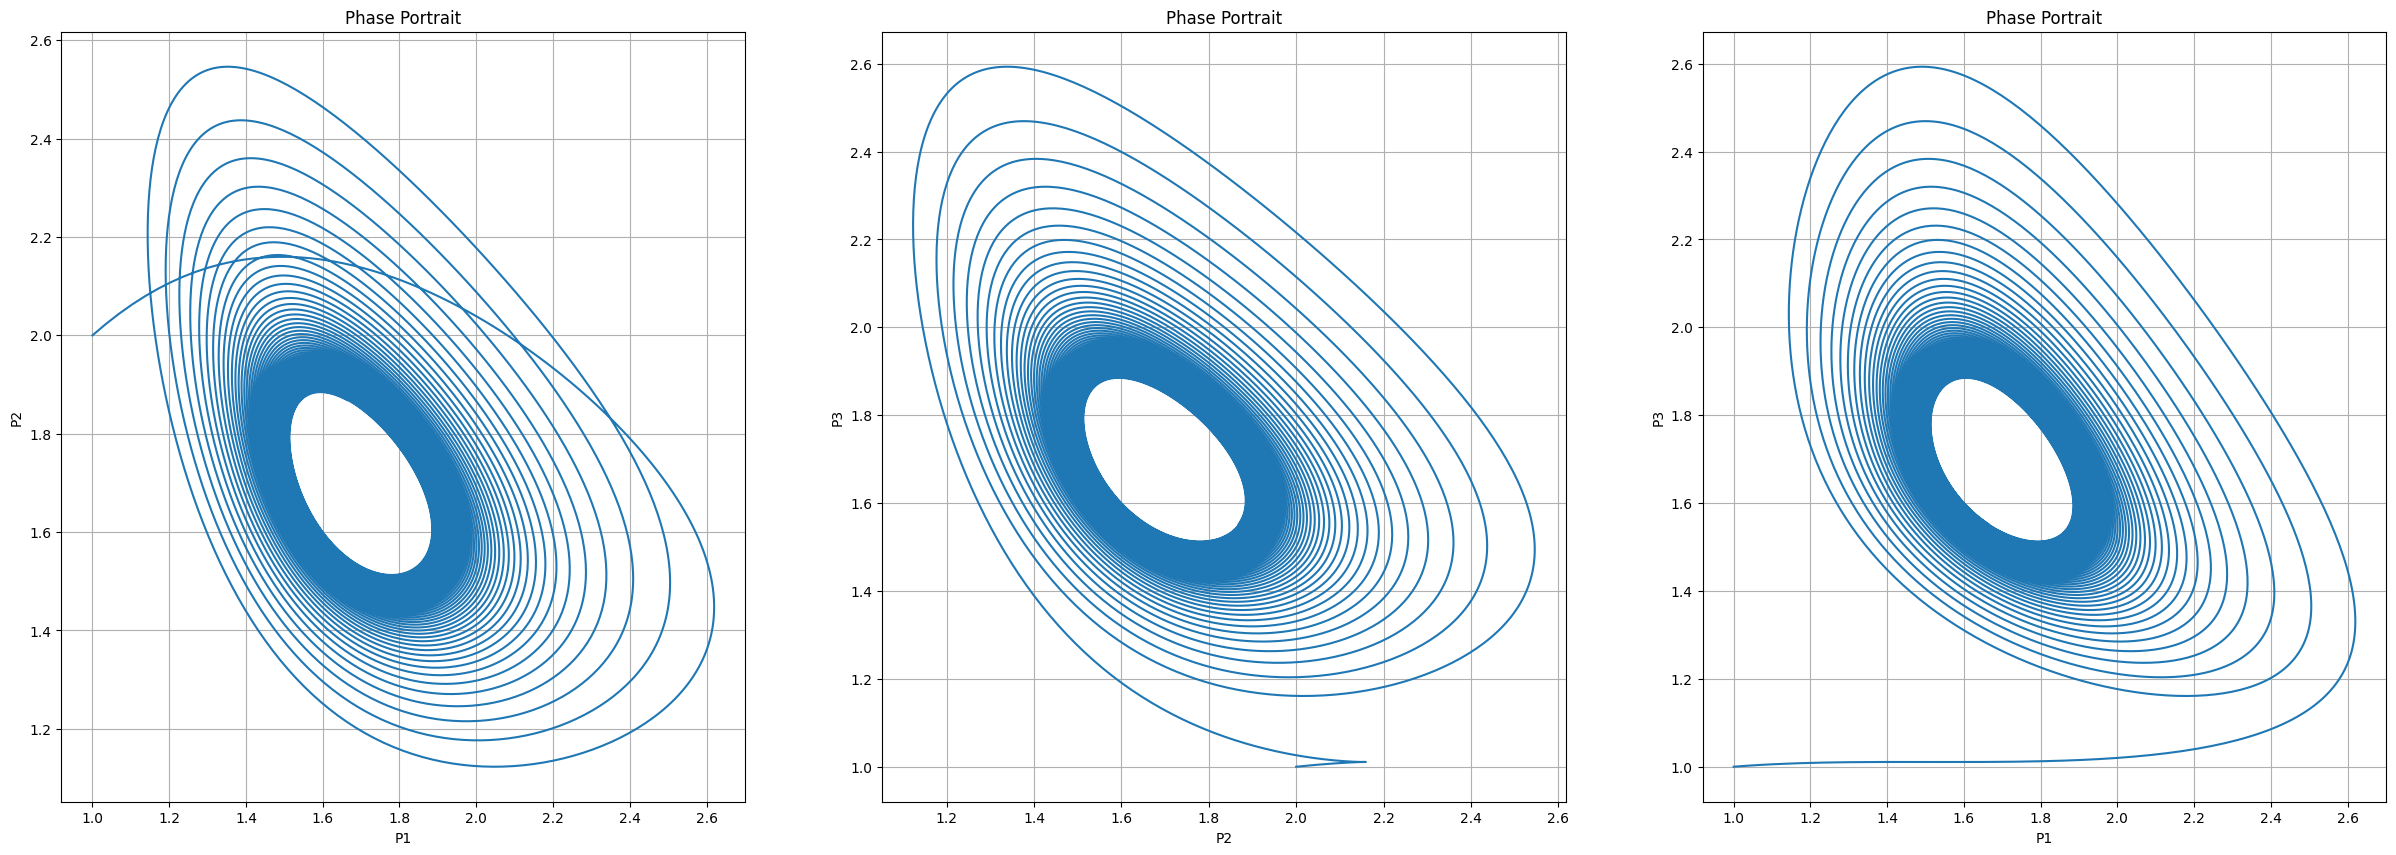

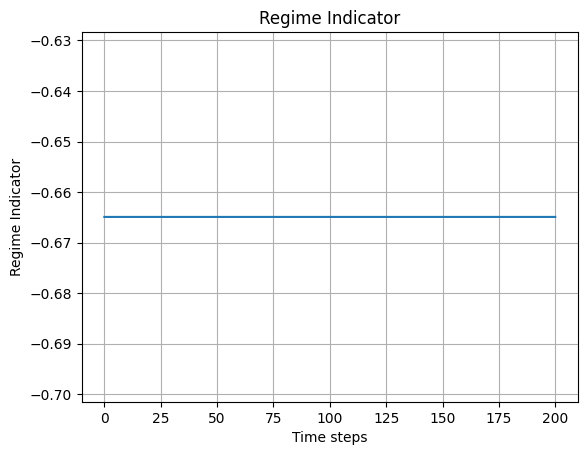

In [40]:
model = Repressilator_one_control(alpha =9.5, gamma = 1.2, n = 2.5)
initial_state = np.array([1, 2, 1])

t, state, u, r, p_eq = model.simulate(initial_state, u0 = 1)
time_series(t, state)
phase_portrait(state)
regime_indicator(t, r)

In [8]:
model = Repressilator_one_control(alpha =9.5, gamma = 1.2, n = 2.5)
model.regime(1), model.regime(1.7)

(np.float64(-0.6649220257072184), np.float64(0.08372297900396397))

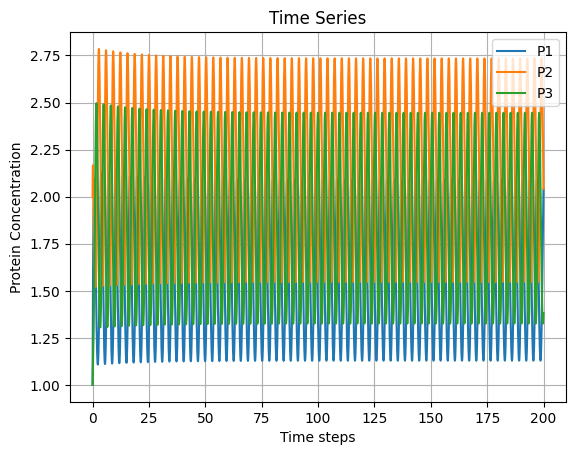

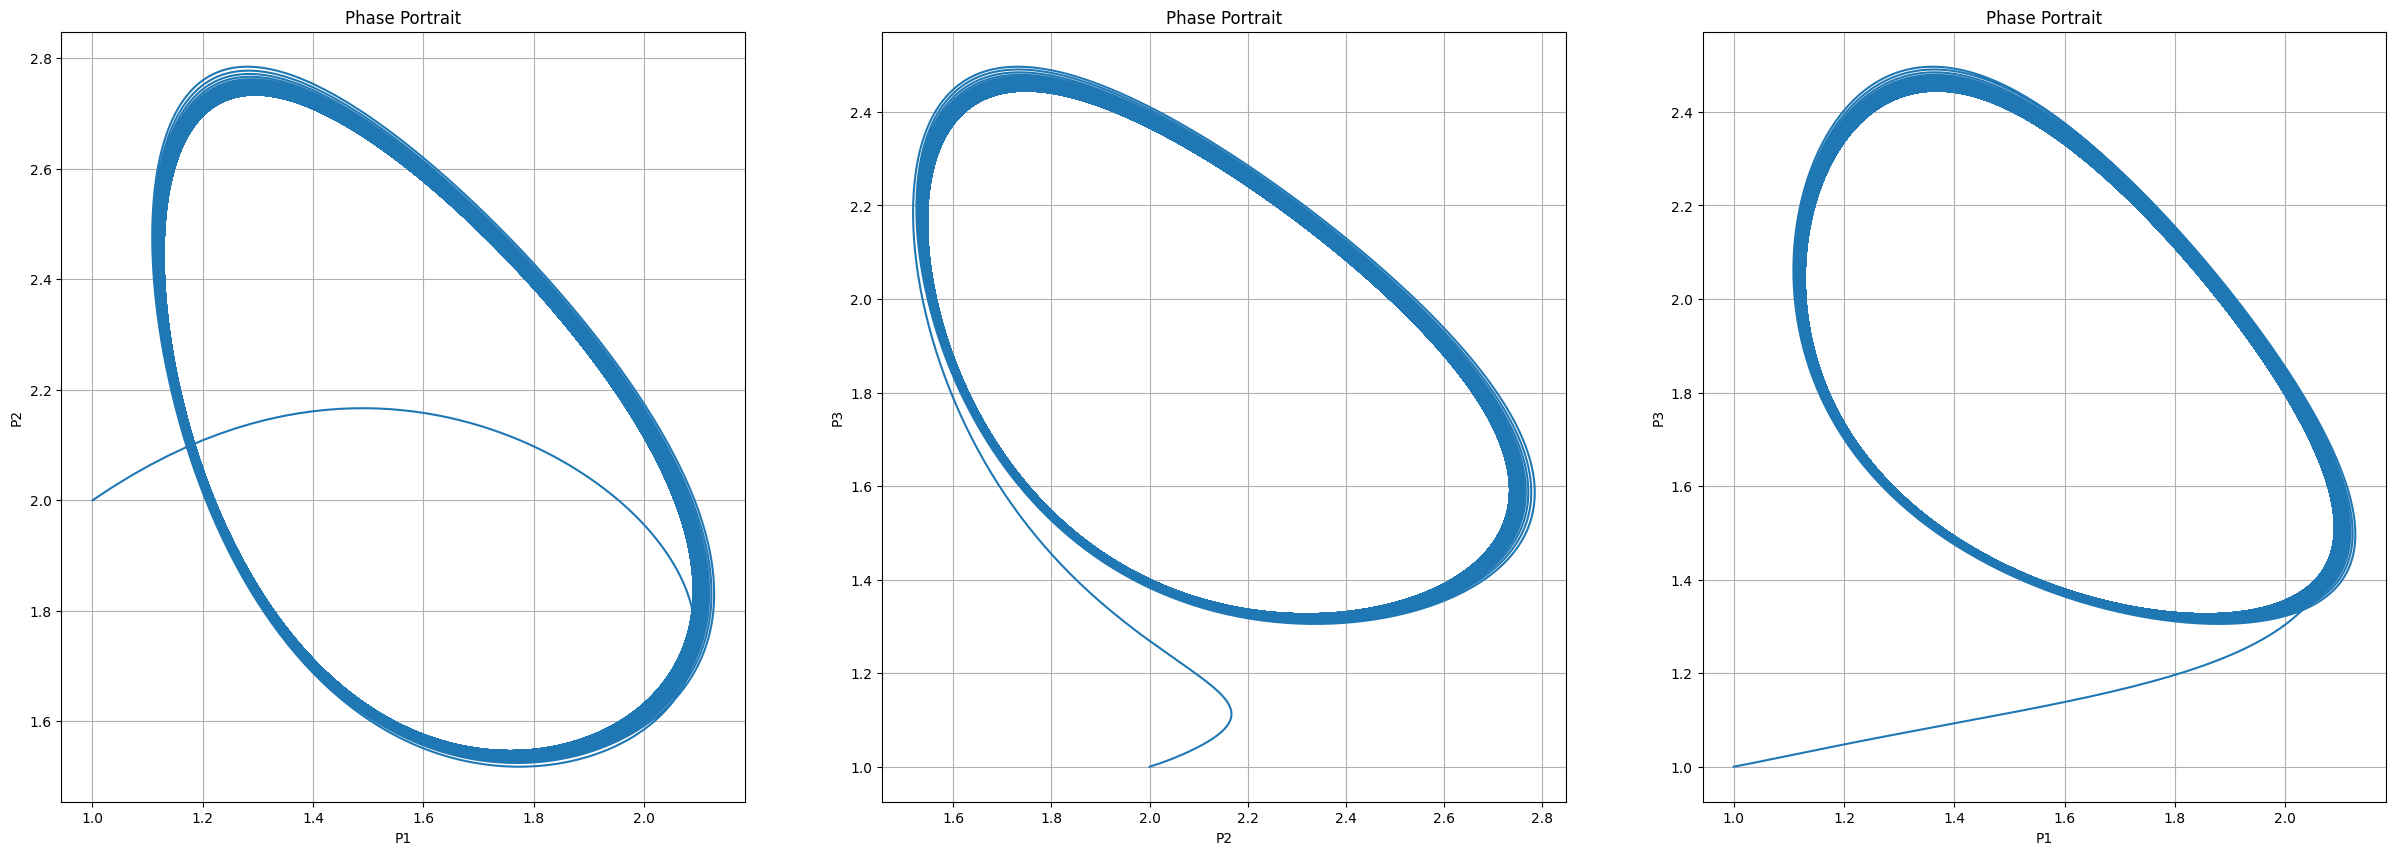

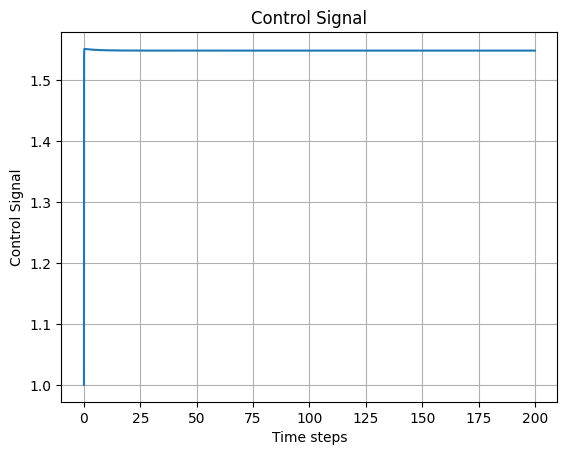

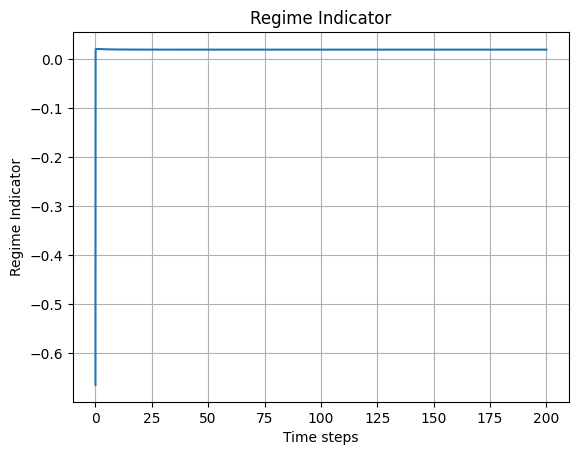

In [16]:
model = Repressilator_one_control(alpha =9.5, gamma = 1.2, n = 2.5)
initial_state = np.array([1, 2, 1])
controller = PID(kp = 0.6, ki = 0.1, kd = 0, target_regime = 0.02)

t, state, u, r, p_eq = model.simulate(initial_state,controller, u0 = 1)
time_series(t, state)
phase_portrait(state)
control_signal(t, u)
regime_indicator(t, r)

Dominant Frequency: 0.28 Hz


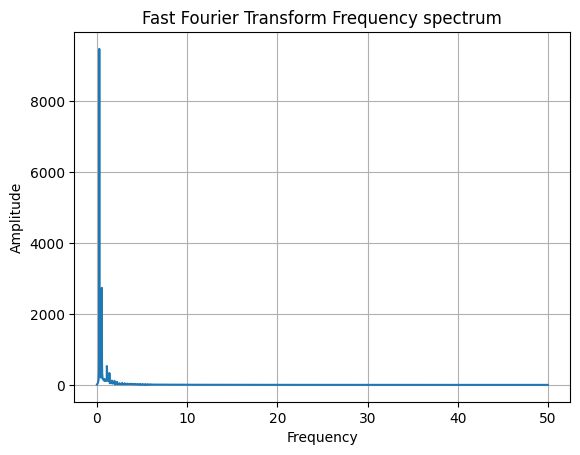

Dominant Frequency: 0.28 Hz


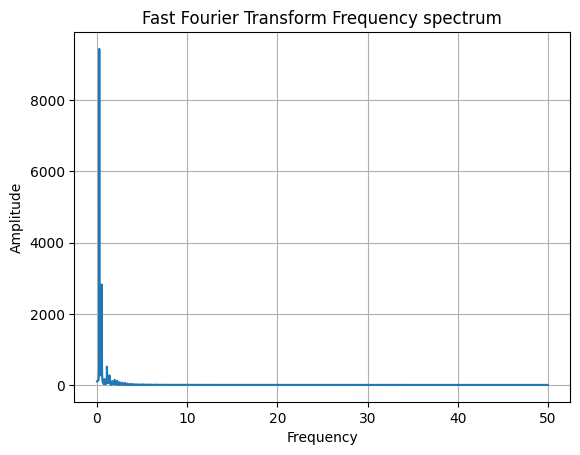

Dominant Frequency: 0.28 Hz


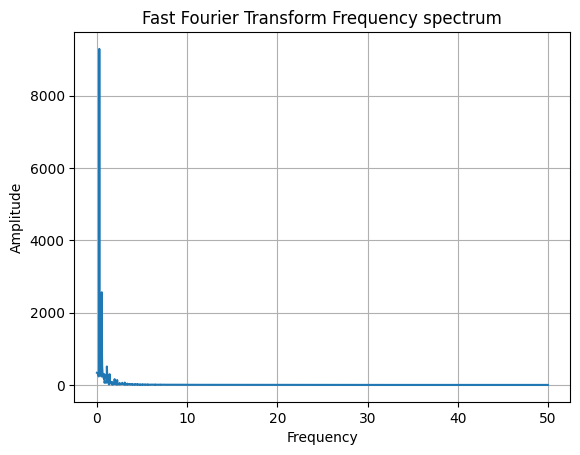

In [122]:
dom_freq, freqs, spectrum = oscillation_freq(state[:,0], 0.01)
print(f"Dominant Frequency: {dom_freq:.2f} Hz")
fft_plot(freqs, spectrum)
dom_freq, freqs, spectrum = oscillation_freq(state[:,1], 0.01)
print(f"Dominant Frequency: {dom_freq:.2f} Hz")
fft_plot(freqs, spectrum)
dom_freq, freqs, spectrum = oscillation_freq(state[:,2], 0.01)
print(f"Dominant Frequency: {dom_freq:.2f} Hz")
fft_plot(freqs, spectrum)